## Concept Bottleneck Model - No Sensor Masking

In [1]:
import random

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import LearningRateScheduler

/home/annemarie/miniconda3/envs/XAI/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
2026-07-22 08:51:00.614212: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784703060.646129 1426284 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784703060.653455 1426284 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-22 08:51:00.682384: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in perfo

In [2]:
TRAIN_SIZE = 8

CONCEPT_NAMES = ['movement_intensity', 'movement_cycle_frequency', 'limb_coordination_imbalance',
                 'ground_impact_force', 'locomotion', 'chest_inclination',
                 'body_elevation', 'arm_role']              # Hard coded to get desired order
CONCEPT_NICE_NAMES = ['Movement Intensity', 'Movement Cycle Frequency', 'Limb Coordination Imbalance',
                      'Ground Impact Force', 'Locomotion', 'Chest Inclination',
                      'Body Elevation', 'Arm Role']
SENSOR_NICE_NAMES = ['Chest Acc.', 'Ankle Acc.', 'Ankle Gyro.', 'Ankle Mag.', 'Arm Acc.', 'Arm Gyro.', 'Arm Mag.']
SENSOR_NICE_NAMES_UNITS = ['Chest Acc.\n(m/s\u00b2)',
 'Ankle Acc.\n(m/s\u00b2)',
 'Ankle Gyro.\n(deg/s)',
 'Ankle Mag.\n(local)',
 'Arm Acc.\n(m/s\u00b2)',
 'Arm Gyro.\n(deg/s)',
 'Arm Mag.\n(local)']

NUMBER_OF_CONCEPTS = len(CONCEPT_NAMES) 

LABEL_NAMES = [
    "Standing",       
    "Sitting",        
    "Lying",          
    "Walking",        
    "Stairs",         
    "WaistBends",     
    "ArmRaise",       
    "KneeBend",       
    "Cycling",        
    "Jogging",        
    "Running",        
    "Jump",         
]

SENSOR_GROUPS = {
    "chest_acc": [0, 1, 2],           
    # "ecg": [3, 4], # ecg sensor is not used                    
    "ankle_acc": [5, 6, 7],         
    "ankle_gyro": [8, 9, 10],        
    "ankle_mag": [11, 12, 13],         
    "arm_acc": [14, 15, 16],       
    "arm_gyro": [17, 18, 19],         
    "arm_mag": [20, 21, 22],          
}

CONCEPT_SENSORS = {
    "chest_inclination":            ["chest_acc"],
    "body_elevation":               ["chest_acc", "ankle_acc", "ankle_gyro"],
    "arm_role":                     ["arm_acc", "arm_gyro", "arm_mag"],
    "ground_impact_force":          ["ankle_acc", "ankle_gyro"],
    "locomotion":                   ["ankle_acc", "ankle_gyro"],
    "movement_cycle_frequency":     ["ankle_acc", "ankle_gyro"],
    "movement_intensity":           ["chest_acc", "arm_acc", "arm_gyro", "arm_mag", "ankle_acc", "ankle_gyro", "ankle_mag"],
    "limb_coordination_imbalance":  ["arm_acc", "arm_gyro", "ankle_acc", "ankle_gyro"],
}

CONCEPT_MEANINGS = {
    "movement_intensity": {
        0: "Static; no movement",
        1: "Low intensity movement",
        2: "Medium intensity movement",
        3: "High intensity movement",
        4: "Extreme intensity movement"
    },
    "locomotion": {
        0: "Subject is stationary",
        1: "Subject is in motion"
    },
    "movement_cycle_frequency": {
        0: "Static; no movement",
        1: "Low frequency movement",
        2: "Medium frequency movement",
        3: "High frequency movement",
        4: "Extreme frequency movement"
    },
    "limb_coordination_imbalance": {
        0: "Symmetrical rest; no movement",
        1: "Symmetrical movement",
        2: "Moderately decoupled movement",
        3: "Severely decoupled movement"
    },
    "chest_inclination": {
        0: "Chest upright",
        1: "Chest inclination variable",
        2: "Chest horizontal"
    },
    "ground_impact_force": {
        0: "No ground impact force",
        1: "Low ground impact force",
        2: "Medium ground impact force",
        3: "High ground impact force"
    },
    "body_elevation": {
        0: "No vertical movement",
        1: "Low vertical movement",
        2: "Medium vertical movement",
        3: "High vertical movement"
    },
    "arm_role": {
        0: "Arms passive / free hang",
        1: "Arms resting / supported",
        2: "Arms active / task-directed",
        3: "Arms in locomotion swing"
    },
}

In [3]:
random.seed(8)
np.random.seed(8)
tf.random.set_seed(8)

## Sensor Data to Concepts

In [4]:
train = pd.DataFrame([])
test = pd.DataFrame([])

for i in range(1, 11):
    # load subject
    subject = pd.read_csv('dataset/mHealth_subject' + str(i) + '.log', sep='\s+', header=None)
    # load concepts
    for folder in CONCEPT_NAMES:
        subject[folder] = pd.read_csv('concepts/' + folder + '/' + folder + '_subject' + str(i) + '.csv')
    # remove 0 label
    subject = subject[subject.iloc[:,23] != 0]
    subject.iloc[:,23] = subject.iloc[:,23] - 1
    # train test split
    if (i <= TRAIN_SIZE):
        train = pd.concat([train, subject], axis=0, ignore_index=True)
    else:
        test = pd.concat([test, subject], axis=0, ignore_index=True)
        
print('number of concepts:', NUMBER_OF_CONCEPTS)
print('train:', train.shape)
print('test:', test.shape)

number of concepts: 8
train: (275151, 32)
test: (68044, 32)


In [5]:
def get_windows(data, sample_rate=50, window_sec=2, overlap=0.5): 
    '''
    Make window segments of data using 'window_sec' and 'overlap' given a 'sample_rate'.
    '''
    window_size = window_sec * sample_rate
    stride = int(window_size * (1 - overlap))
    
    windows = []
    
    # drops any remaining data that doesn't fit the window
    for start in range(0, len(data) - window_size + 1, stride): 
        end = start+ window_size
        window = data[start:end]
        windows.append(window)

    return np.array(windows), window_size

In [6]:
def normalize(train, test):
    '''
    Normalize both train and test sets by only fitting on the train set.
    '''
    train_flat = train.reshape(-1, train.shape[-1])  
    test_flat  = test.reshape(-1, test.shape[-1])  
    
    scaler = StandardScaler()
    scaler.fit(train_flat)
    
    train = scaler.transform(train_flat).reshape(train.shape)
    test  = scaler.transform(test_flat).reshape(test.shape)
    
    return train, test, scaler

In [7]:
def get_most_frequent(x):
    '''
    Change shape from (# windows, # samples, # features) to (# windows, # features) by selecting the most frequently
    appearing sample from each window.
    '''
    x = stats.mode(x, axis=1, keepdims=False)[0]
    
    return x

In [8]:
def sensor_concept_label_split(train, test):
    '''
    Preprocess and extract sensor, concept, and label sets from a train and test set.
    '''
    train_sensors = train.iloc[:, :-NUMBER_OF_CONCEPTS]    
    test_sensors = test.iloc[:, :-NUMBER_OF_CONCEPTS] 
    
    train_sensors, w = get_windows(train_sensors)
    test_sensors, w = get_windows(test_sensors)
    
    train_concepts = train.iloc[:, -NUMBER_OF_CONCEPTS:] 
    test_concepts = test.iloc[:, -NUMBER_OF_CONCEPTS:] 
    
    train_concepts, w = get_windows(train_concepts)
    test_concepts, w = get_windows(test_concepts)
    
    # ensure concepts are numeric
    train_concepts = np.asarray(train_concepts).astype('float32')
    test_concepts = np.asarray(test_concepts).astype('float32')
    
    train_concepts = get_most_frequent(train_concepts)
    test_concepts = get_most_frequent(test_concepts)
    
    train_labels = train_sensors[:, :, 23]
    test_labels = test_sensors[:, :, 23]
    
    train_labels = get_most_frequent(train_labels)
    test_labels = get_most_frequent(test_labels)

    train_sensors = np.delete(train_sensors, 23, axis=2)
    test_sensors = np.delete(test_sensors, 23, axis=2)
    
    train_sensors, test_sensors, sensor_scaler = normalize(train_sensors, test_sensors)
    train_concepts, test_concepts, concept_scaler = normalize(train_concepts, test_concepts)
    
    return train_sensors, test_sensors, train_concepts, test_concepts, train_labels, test_labels, w, concept_scaler

In [9]:
train_sensors, test_sensors, train_concepts, test_concepts, train_labels, test_labels, w, concept_scaler = sensor_concept_label_split(train, test)

print('train_sensors:', train_sensors.shape)
print('test_sensors:', test_sensors.shape)
print('train_concepts:', train_concepts.shape)
print('test_concepts:', test_concepts.shape)
print('train_labels:', train_labels.shape)
print('test_labels:', test_labels.shape)

train_sensors: (5502, 100, 23)
test_sensors: (1359, 100, 23)
train_concepts: (5502, 8)
test_concepts: (1359, 8)
train_labels: (5502,)
test_labels: (1359,)


In [10]:
input_list = []
train_sensors_groups = []
test_sensors_groups = []

for group in SENSOR_GROUPS.values():
    input_list.append(Input(shape=(w, len(group))))
    train_sensors_groups.append(train_sensors[:, :, group])
    test_sensors_groups.append(test_sensors[:, :, group])

def branch(inp):
    x = LSTM(64, return_sequences=True, recurrent_dropout=0.2)(inp)
    x = Dropout(0.3)(x)
    x = LSTM(32, return_sequences=False, recurrent_dropout=0.2)(x)
    x = Dropout(0.3)(x)
    return x

branch_list = []

for inp in input_list:
    branch_list.append(branch(inp))

merged = Concatenate(axis=-1)(branch_list) 

output = Dense(NUMBER_OF_CONCEPTS, activation='linear')(merged)

sensors_to_concepts = Model(inputs=input_list, outputs=output)

W0000 00:00:1784703076.458779 1426284 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [11]:
sensors_to_concepts.compile(optimizer=Adam(learning_rate=1e-3), loss=Huber(delta=1.0), metrics=['mae'])

# change learning rate after certain amount of epochs without recompiling and resetting optimiser
def lr_schedule(epoch, lr):
    if epoch == 10:
        return 1e-4 
    return lr

scheduler = LearningRateScheduler(lr_schedule, verbose=0)
sensors_to_concepts.fit(train_sensors_groups, train_concepts, validation_data=(test_sensors_groups, test_concepts), epochs=30, batch_size=64, callbacks=[scheduler], verbose=2)

Epoch 1/30
86/86 - 79s - 922ms/step - loss: 0.1941 - mae: 0.4908 - val_loss: 0.0812 - val_mae: 0.2883 - learning_rate: 0.0010
Epoch 2/30
86/86 - 25s - 286ms/step - loss: 0.0834 - mae: 0.3085 - val_loss: 0.0373 - val_mae: 0.1921 - learning_rate: 0.0010
Epoch 3/30
86/86 - 24s - 273ms/step - loss: 0.0601 - mae: 0.2570 - val_loss: 0.0333 - val_mae: 0.1695 - learning_rate: 0.0010
Epoch 4/30
86/86 - 24s - 275ms/step - loss: 0.0488 - mae: 0.2296 - val_loss: 0.0266 - val_mae: 0.1511 - learning_rate: 0.0010
Epoch 5/30
86/86 - 24s - 278ms/step - loss: 0.0489 - mae: 0.2252 - val_loss: 0.0260 - val_mae: 0.1504 - learning_rate: 0.0010
Epoch 6/30
86/86 - 24s - 276ms/step - loss: 0.0359 - mae: 0.1928 - val_loss: 0.0225 - val_mae: 0.1348 - learning_rate: 0.0010
Epoch 7/30
86/86 - 24s - 277ms/step - loss: 0.0345 - mae: 0.1855 - val_loss: 0.0232 - val_mae: 0.1357 - learning_rate: 0.0010
Epoch 8/30
86/86 - 24s - 279ms/step - loss: 0.0318 - mae: 0.1774 - val_loss: 0.0562 - val_mae: 0.1813 - learning_rate:

In [12]:
# save the model as h5
sensors_to_concepts.save("models/sensors_to_concepts_model.h5")

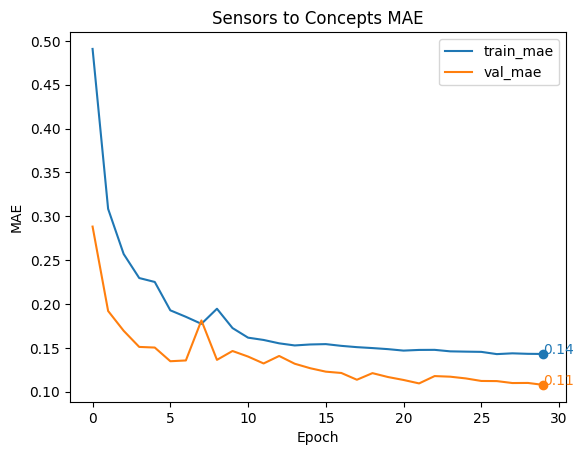

In [13]:
plt.plot(sensors_to_concepts.history.history['mae'], label='train_mae')
plt.plot(sensors_to_concepts.history.history['val_mae'], label='val_mae')
plt.title('Sensors to Concepts MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

for line in plt.gca().get_lines():
    xdata, ydata = line.get_xdata(), line.get_ydata()
    plt.scatter(xdata[-1], ydata[-1], color=line.get_color())
    plt.text(xdata[-1], ydata[-1], f'{ydata[-1]:.2f}', color=line.get_color())

plt.savefig('figures/no_mask_sensors_concepts_mae.pdf', bbox_inches='tight')
plt.show()

In [14]:
predictions = sensors_to_concepts.predict(test_sensors_groups)
pred_mae = np.mean(np.abs(predictions - test_concepts), axis=0)

43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step


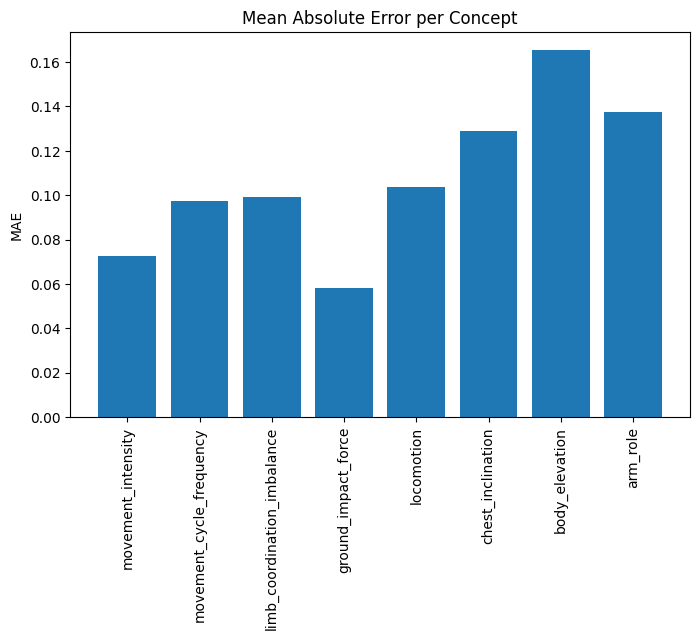

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(CONCEPT_NAMES, pred_mae)
plt.ylabel('MAE')
plt.title('Mean Absolute Error per Concept')
plt.xticks(rotation=90)
plt.savefig('figures/no_mask_mae_per_concept.pdf', bbox_inches='tight')
plt.show()

In [16]:
def randomise_sensor_groups(sensor_groups, keep_index=[]):

    randomised_groups = []

    for i, group in enumerate(sensor_groups):
        if i not in keep_index:
            randomised_groups.append(group.copy())
            continue

        n_windows, n_points, n_sensors = group.shape
        randomised_group = np.empty_like(group)

        for s in range(n_sensors):
            # flatten all data for this sensor
            flat_data = group[..., s].ravel()
            # shuffle data
            shuffled = np.random.permutation(flat_data)
            # reshape back to original
            randomised_group[..., s] = shuffled.reshape(n_windows, n_points)

        randomised_groups.append(randomised_group)

    return randomised_groups

In [17]:
maes = []
for i, _ in enumerate(test_sensors_groups):
    sensor_group_noised = randomise_sensor_groups(test_sensors_groups, [i])
    predictions_noised = sensors_to_concepts.predict(sensor_group_noised)
    mae = np.mean(np.abs(predictions_noised - test_concepts), axis=0)
    maes.append(mae - pred_mae)
    
perm_per_group = np.array(maes).T

 1/43 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step


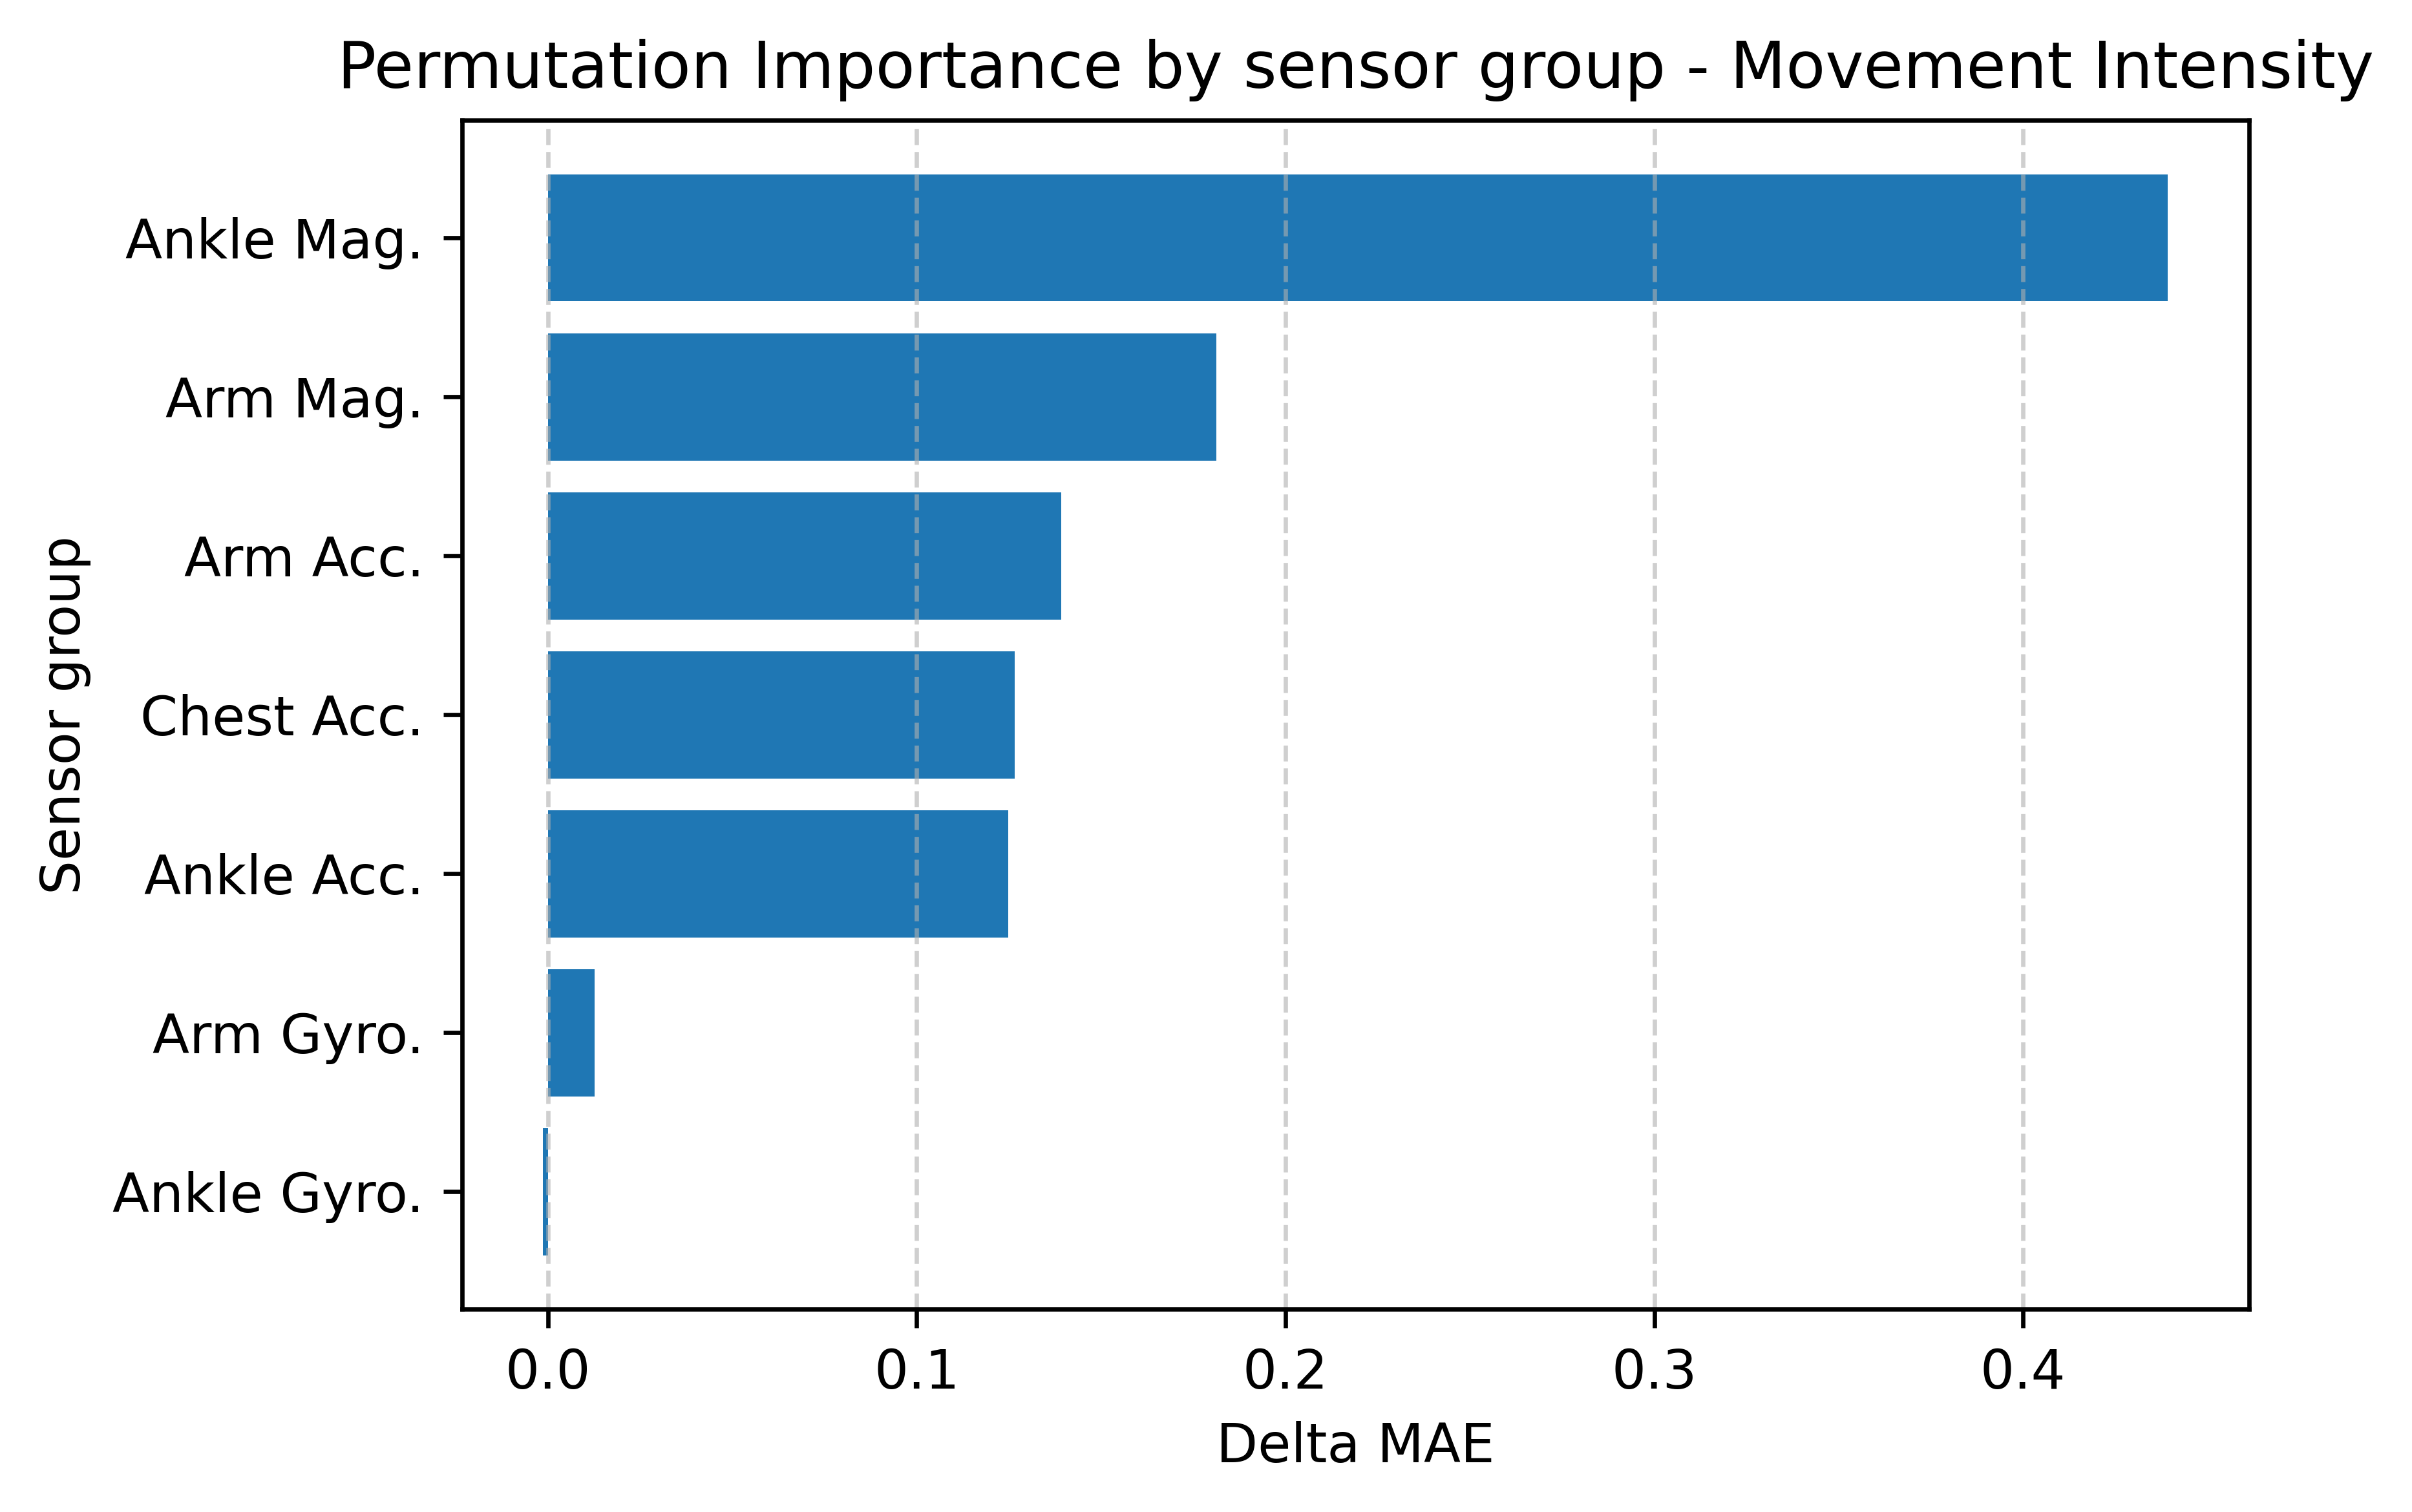

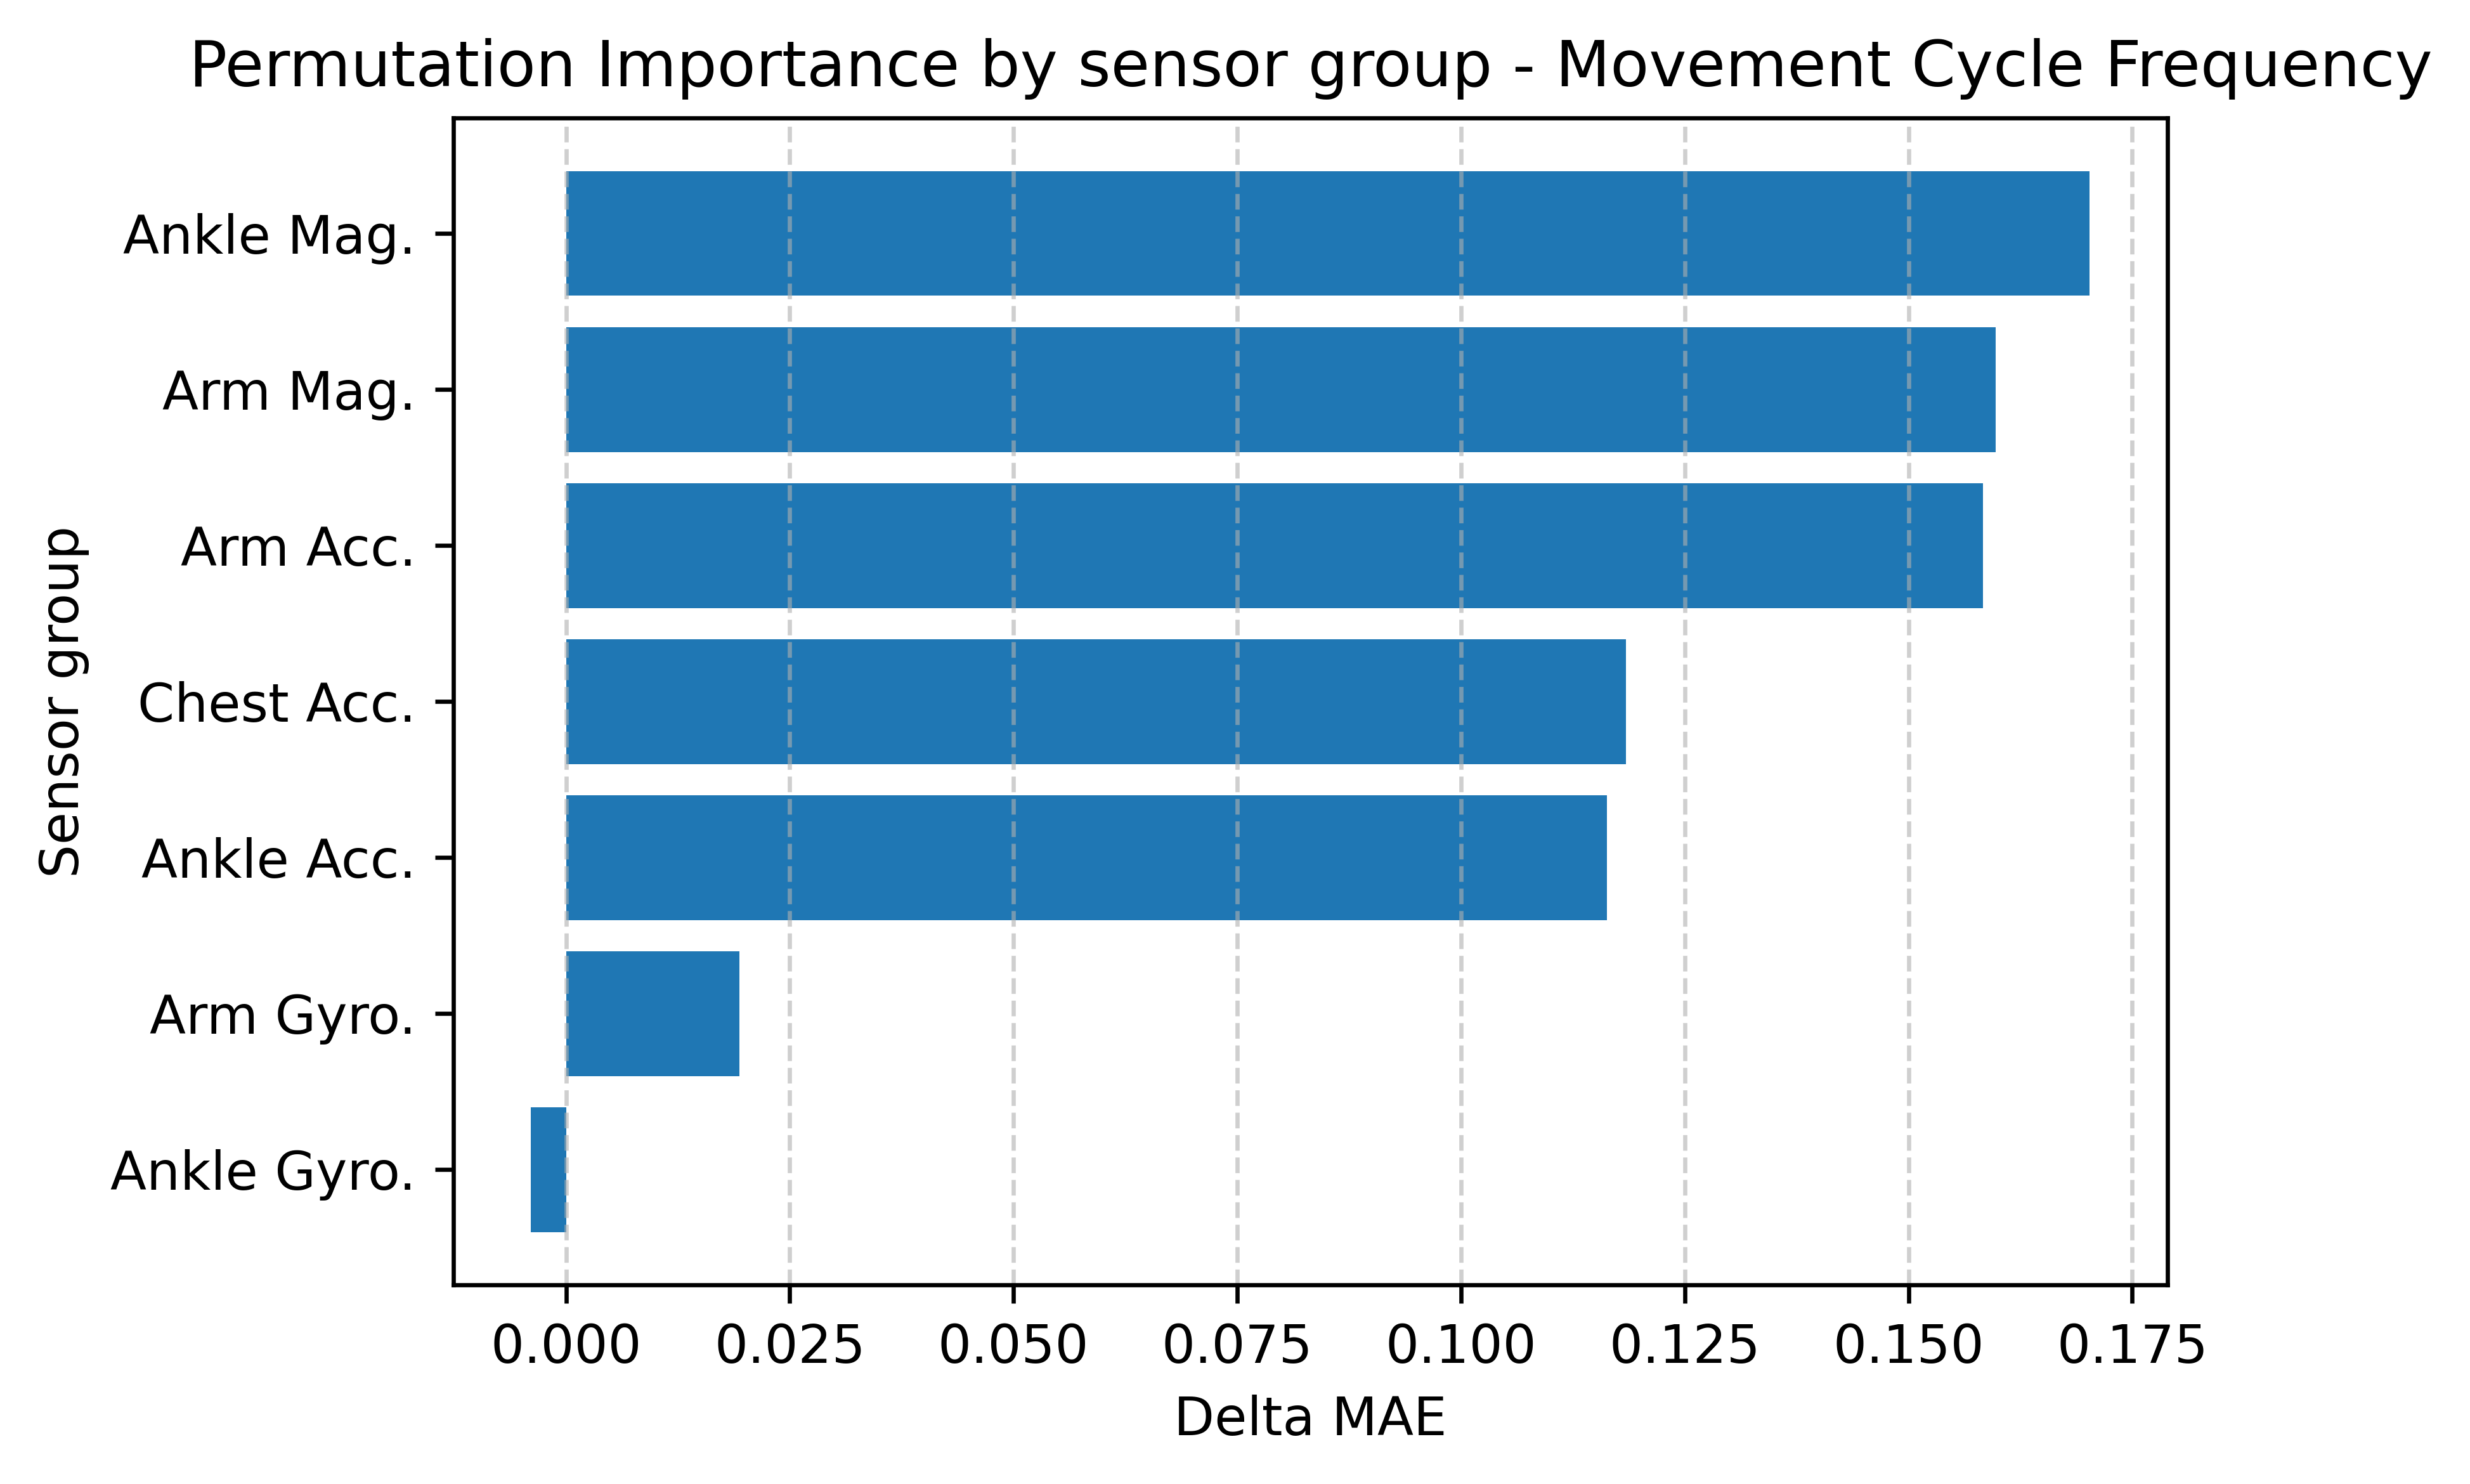

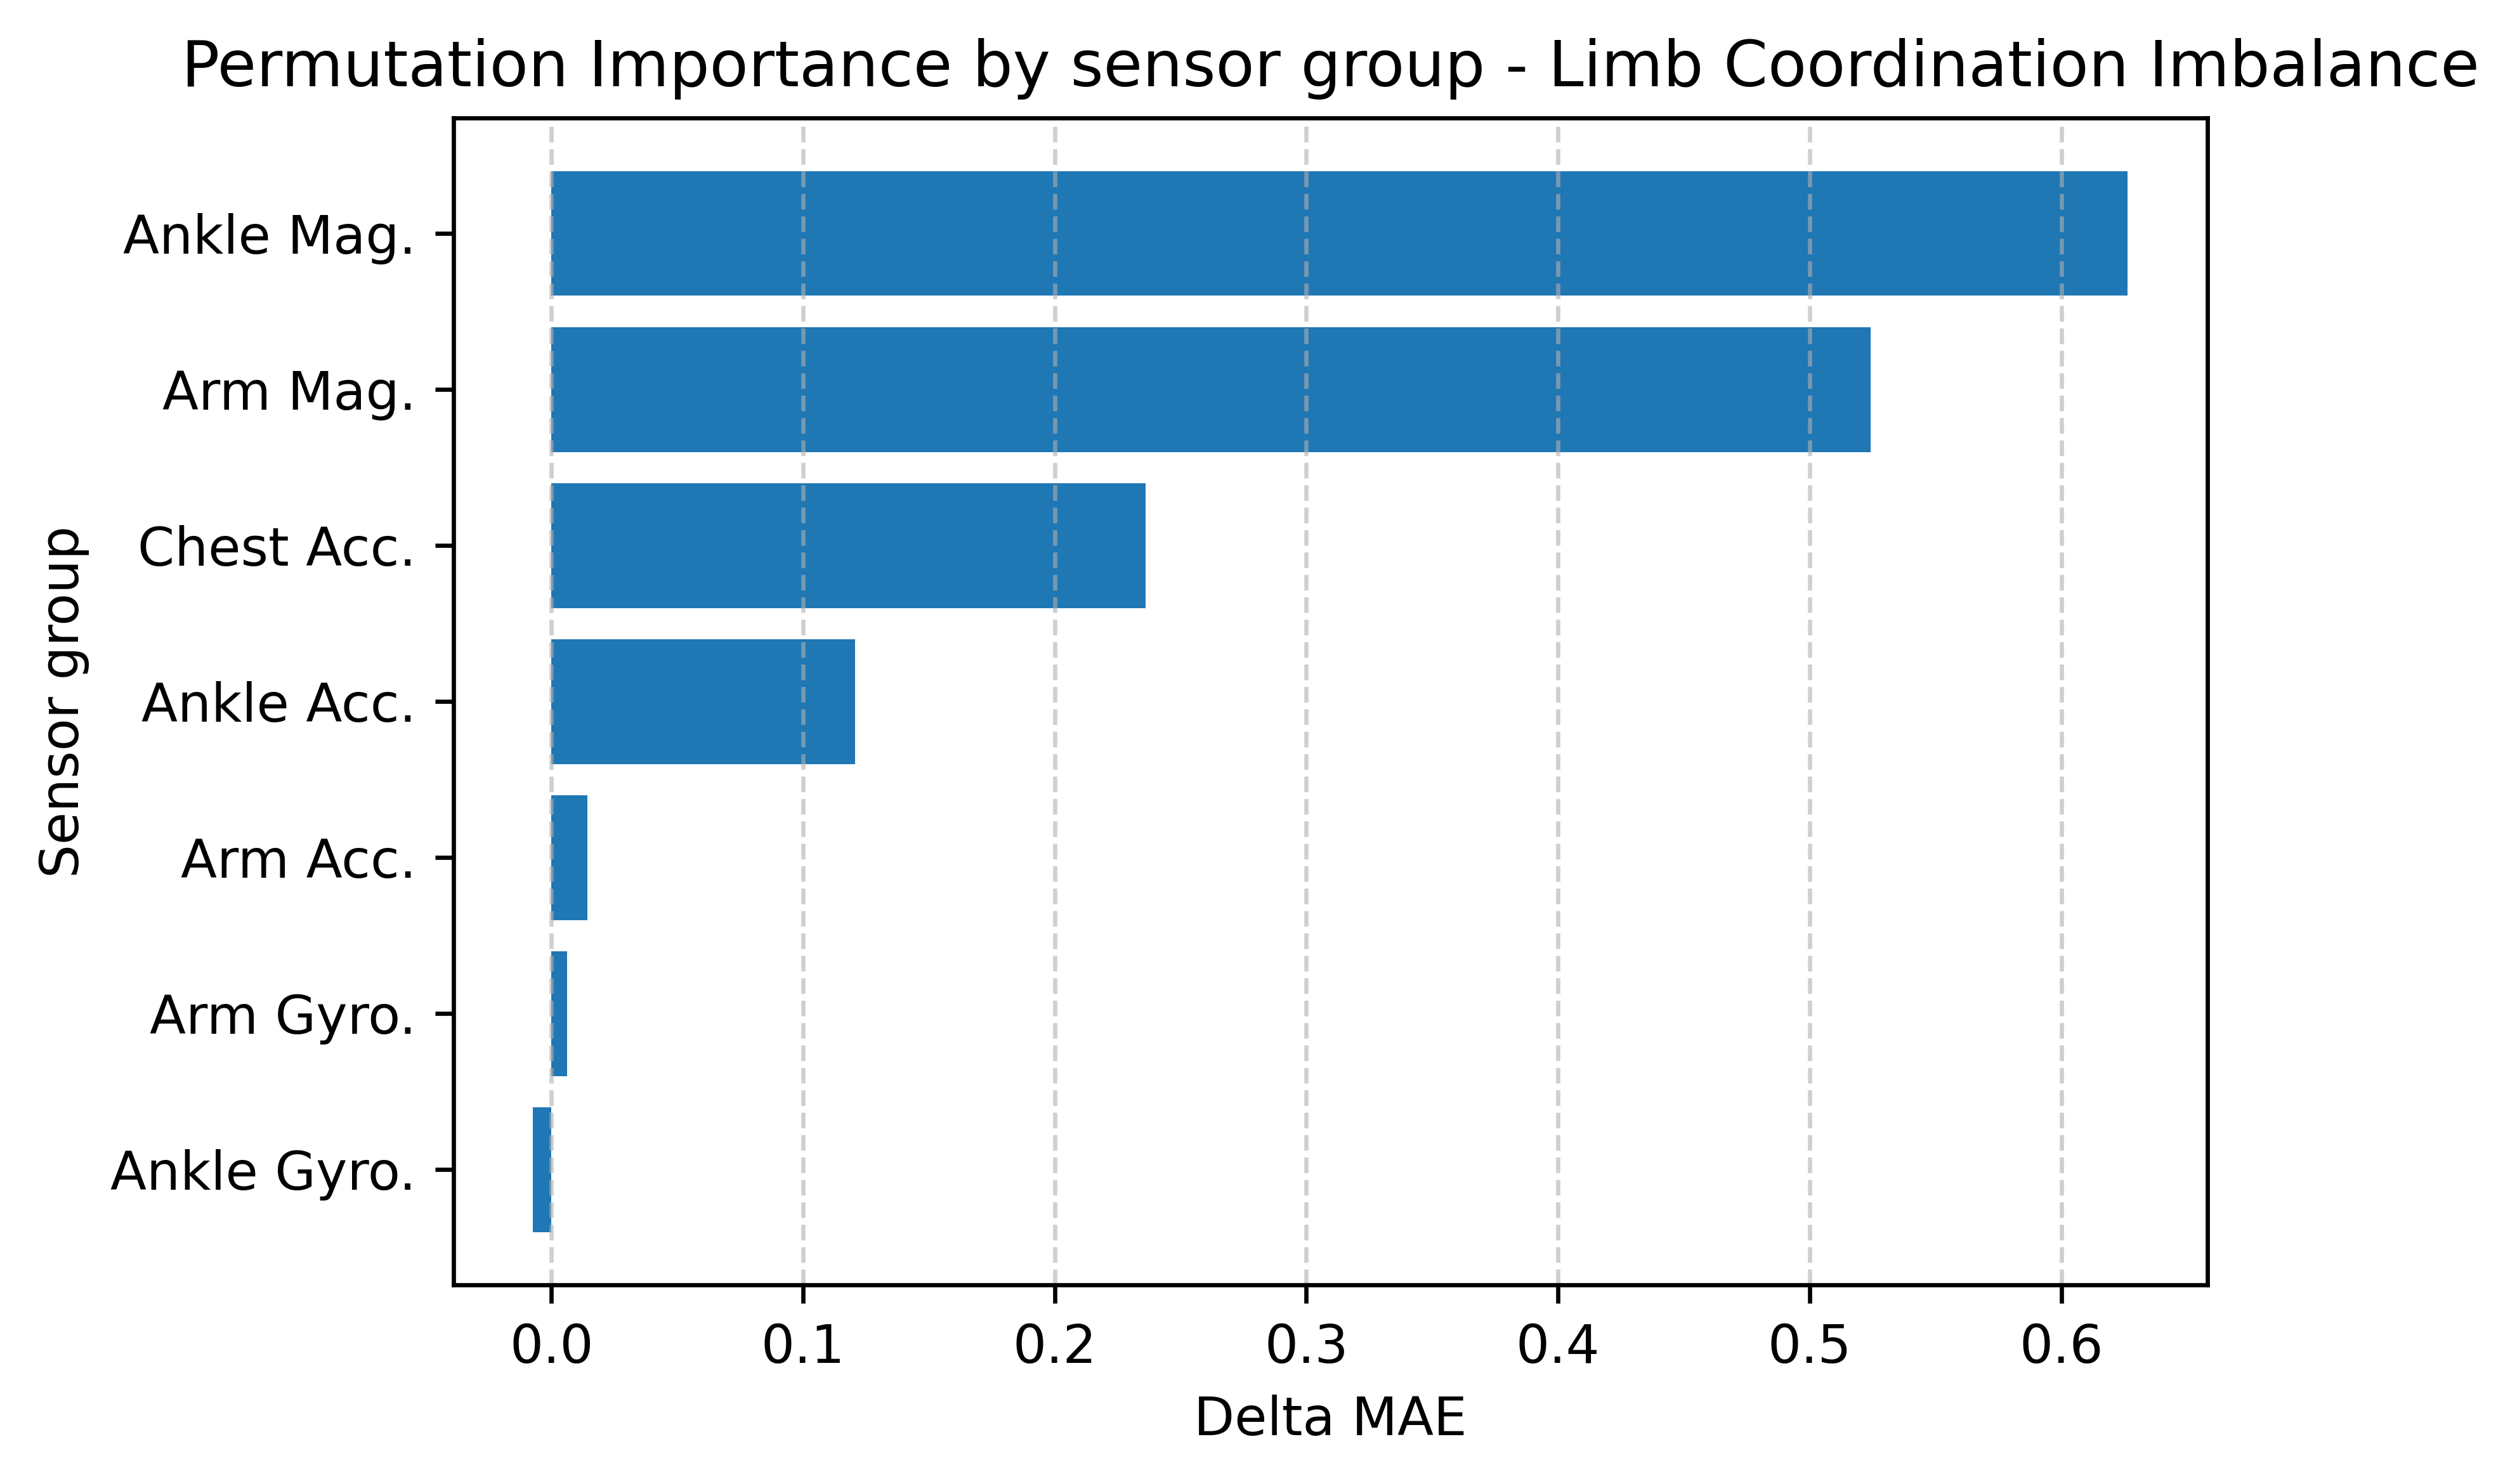

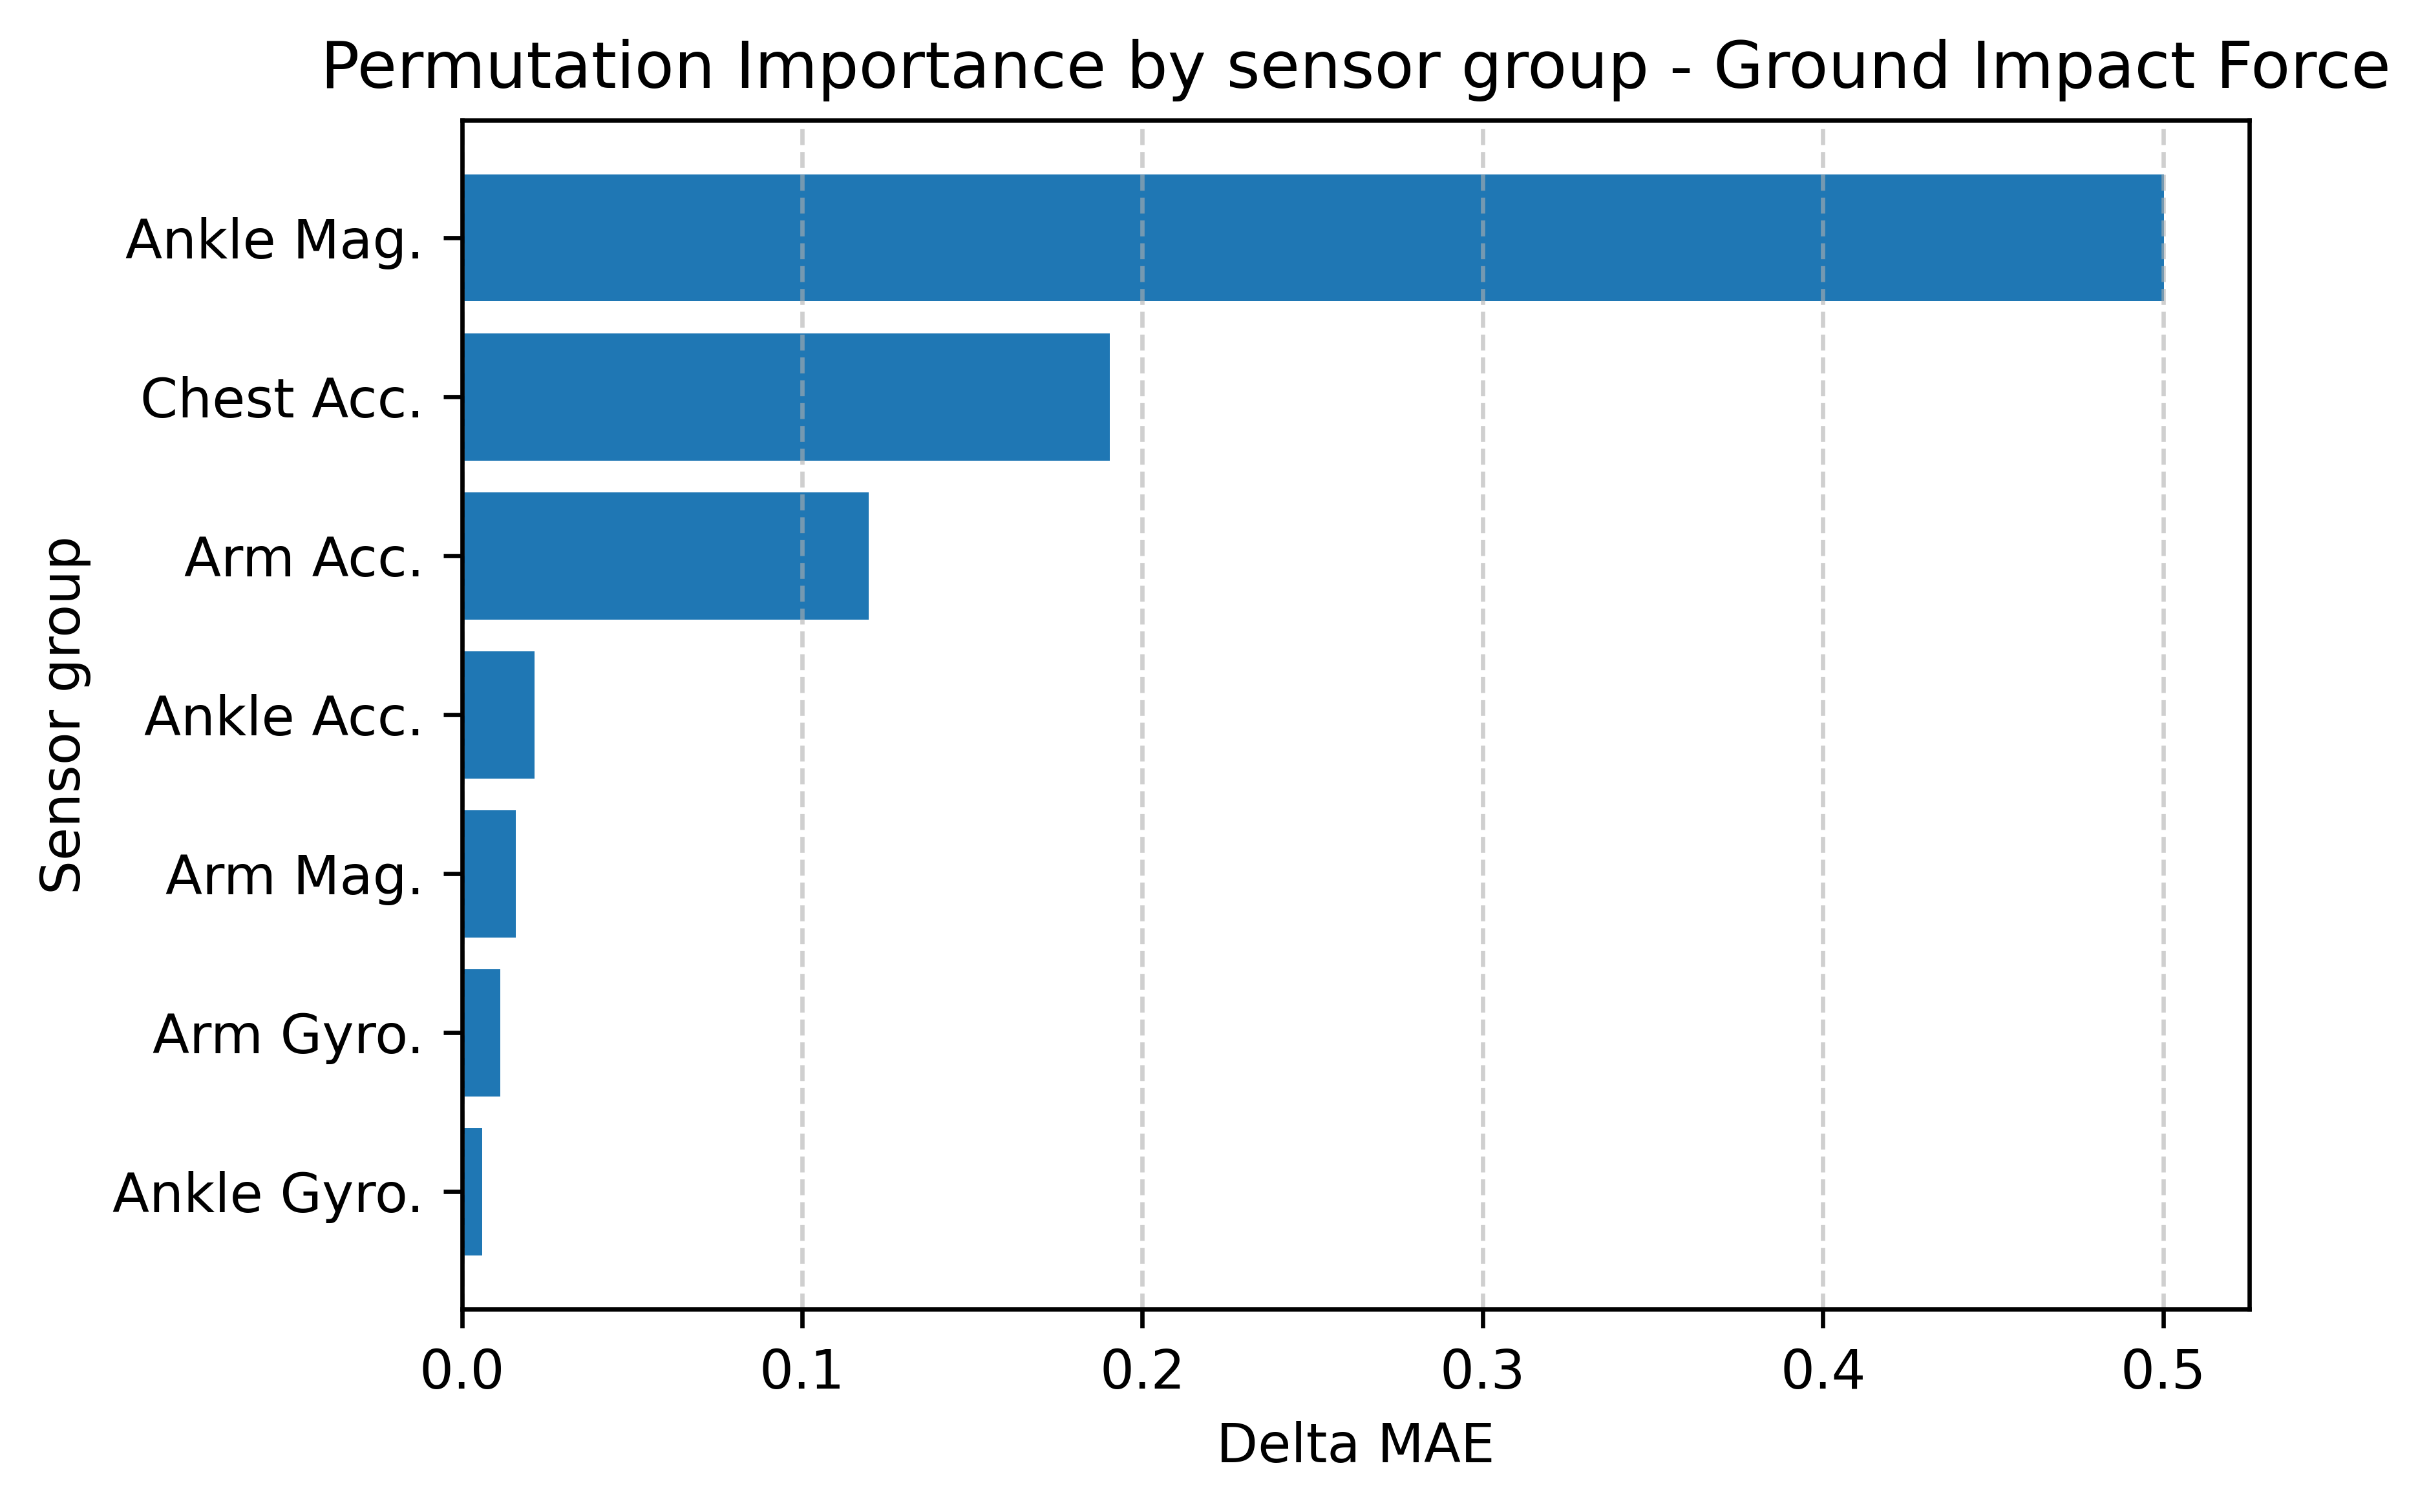

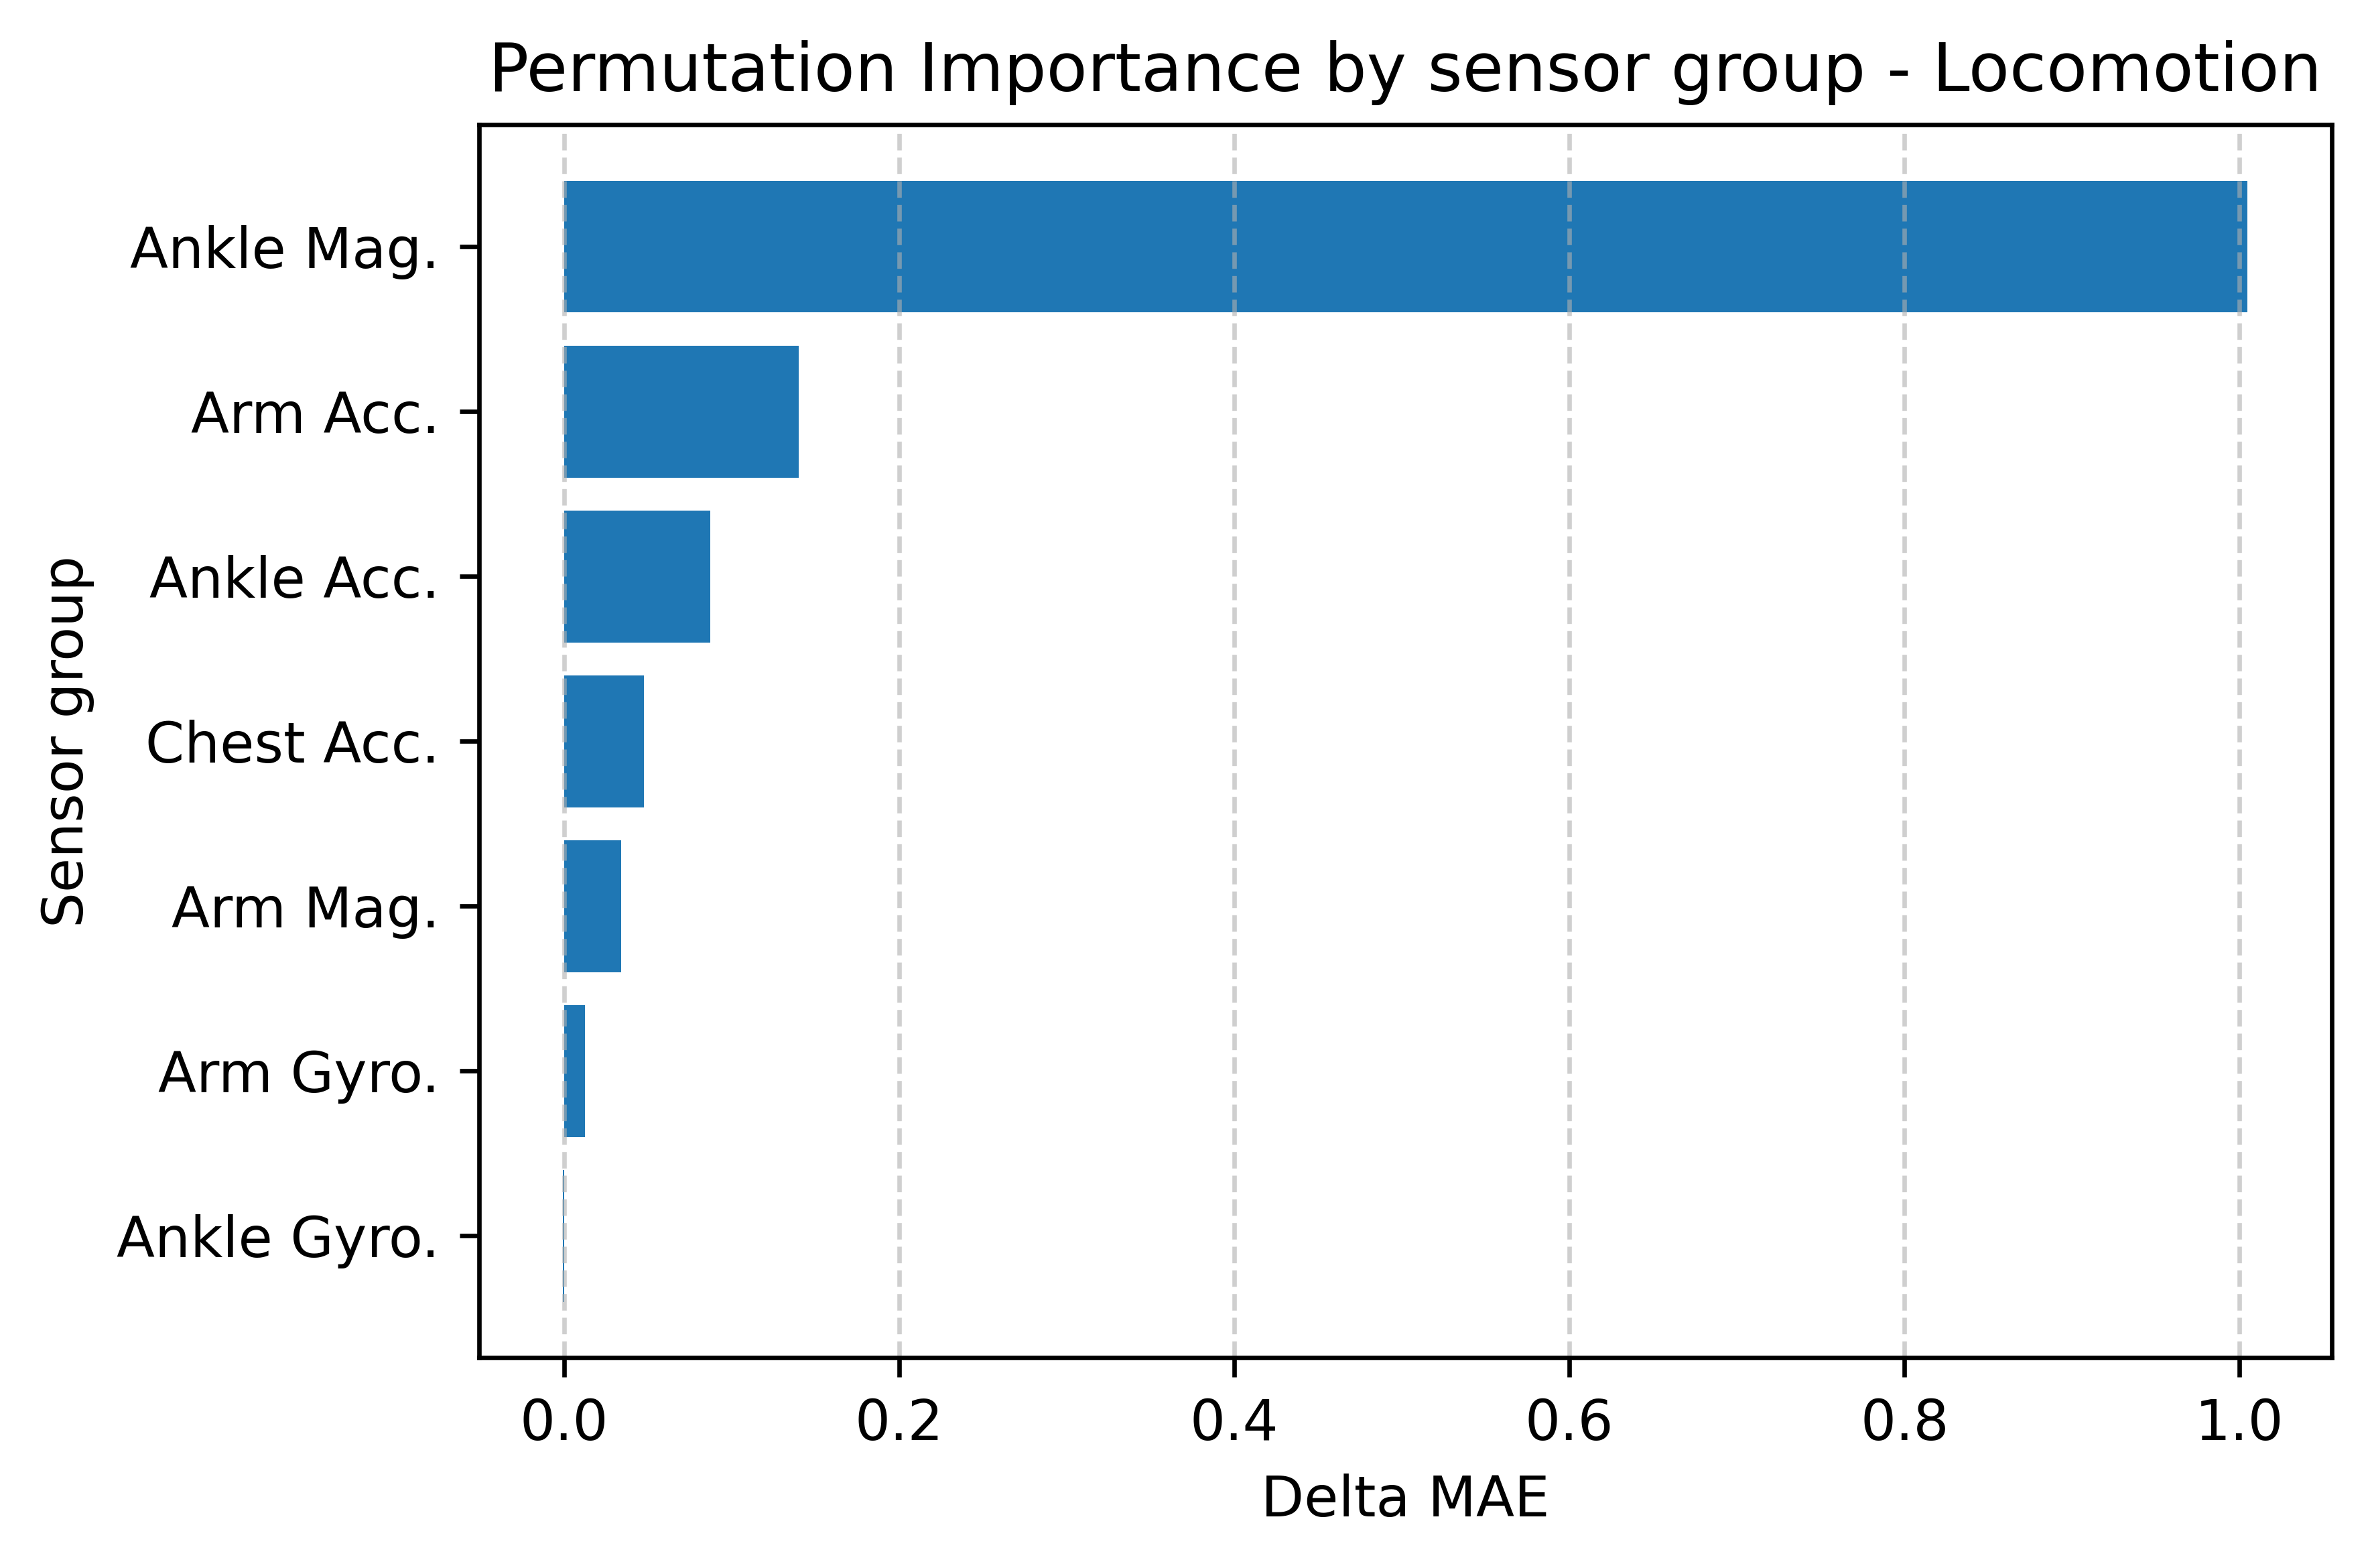

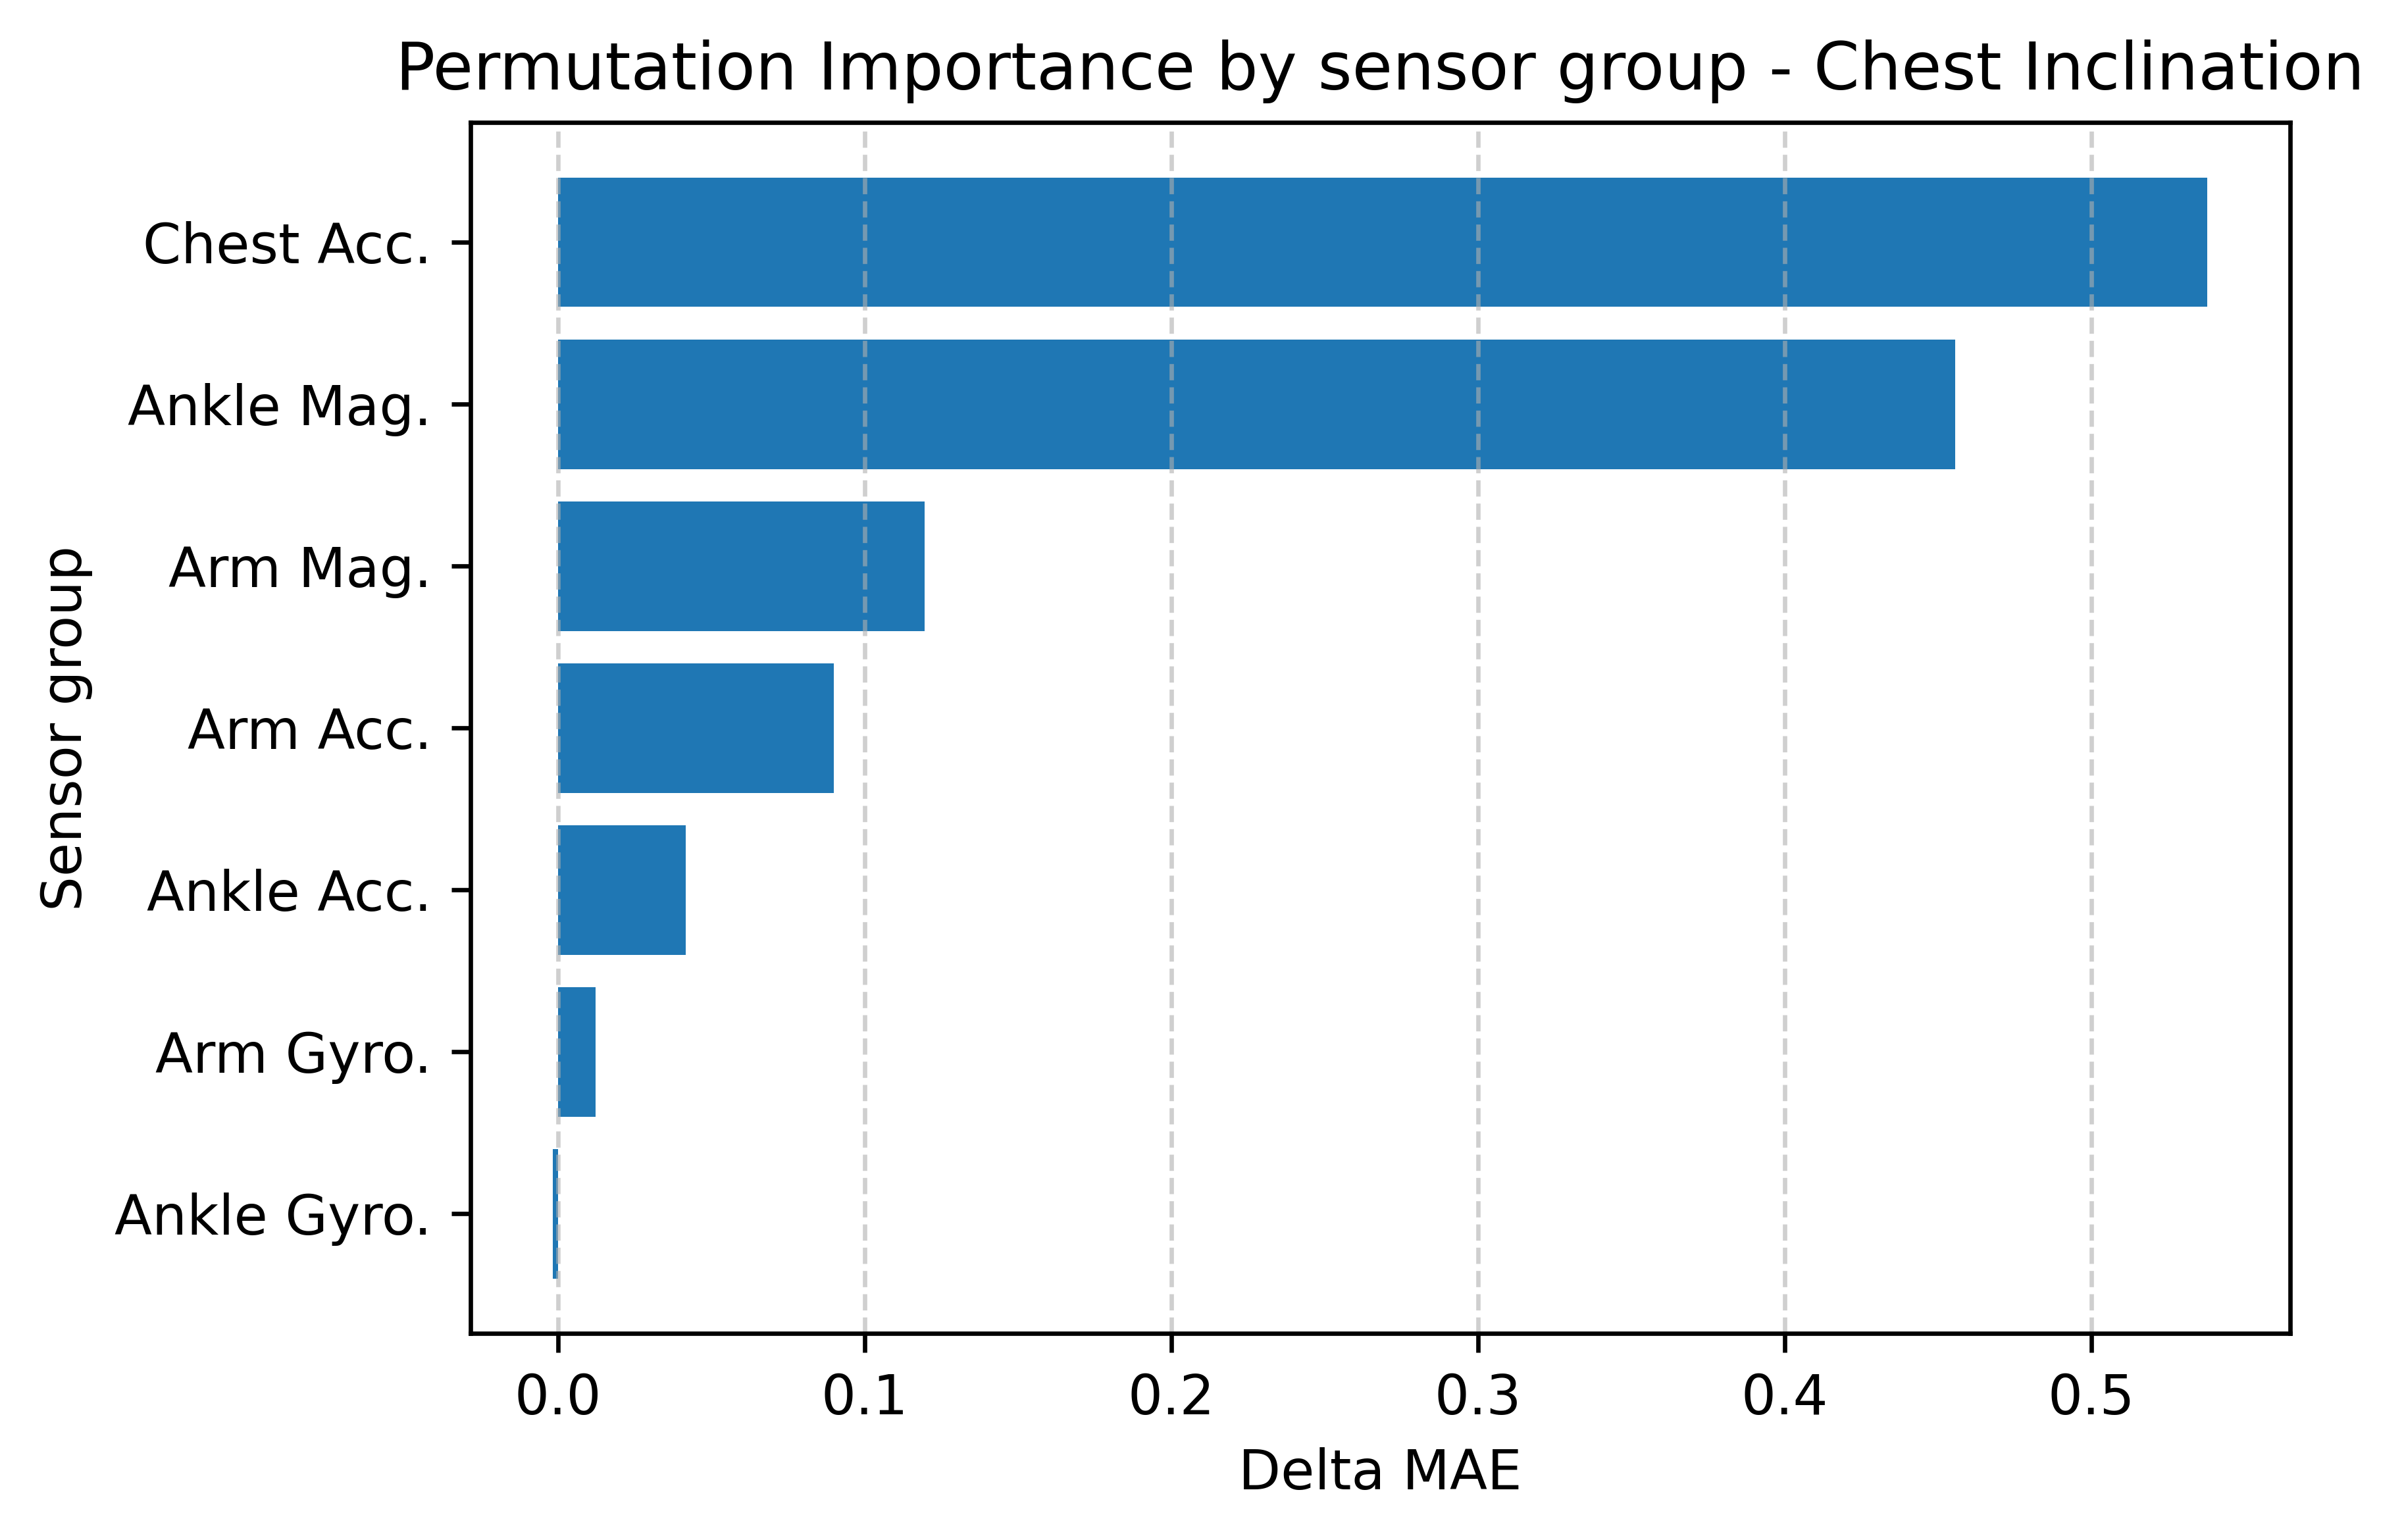

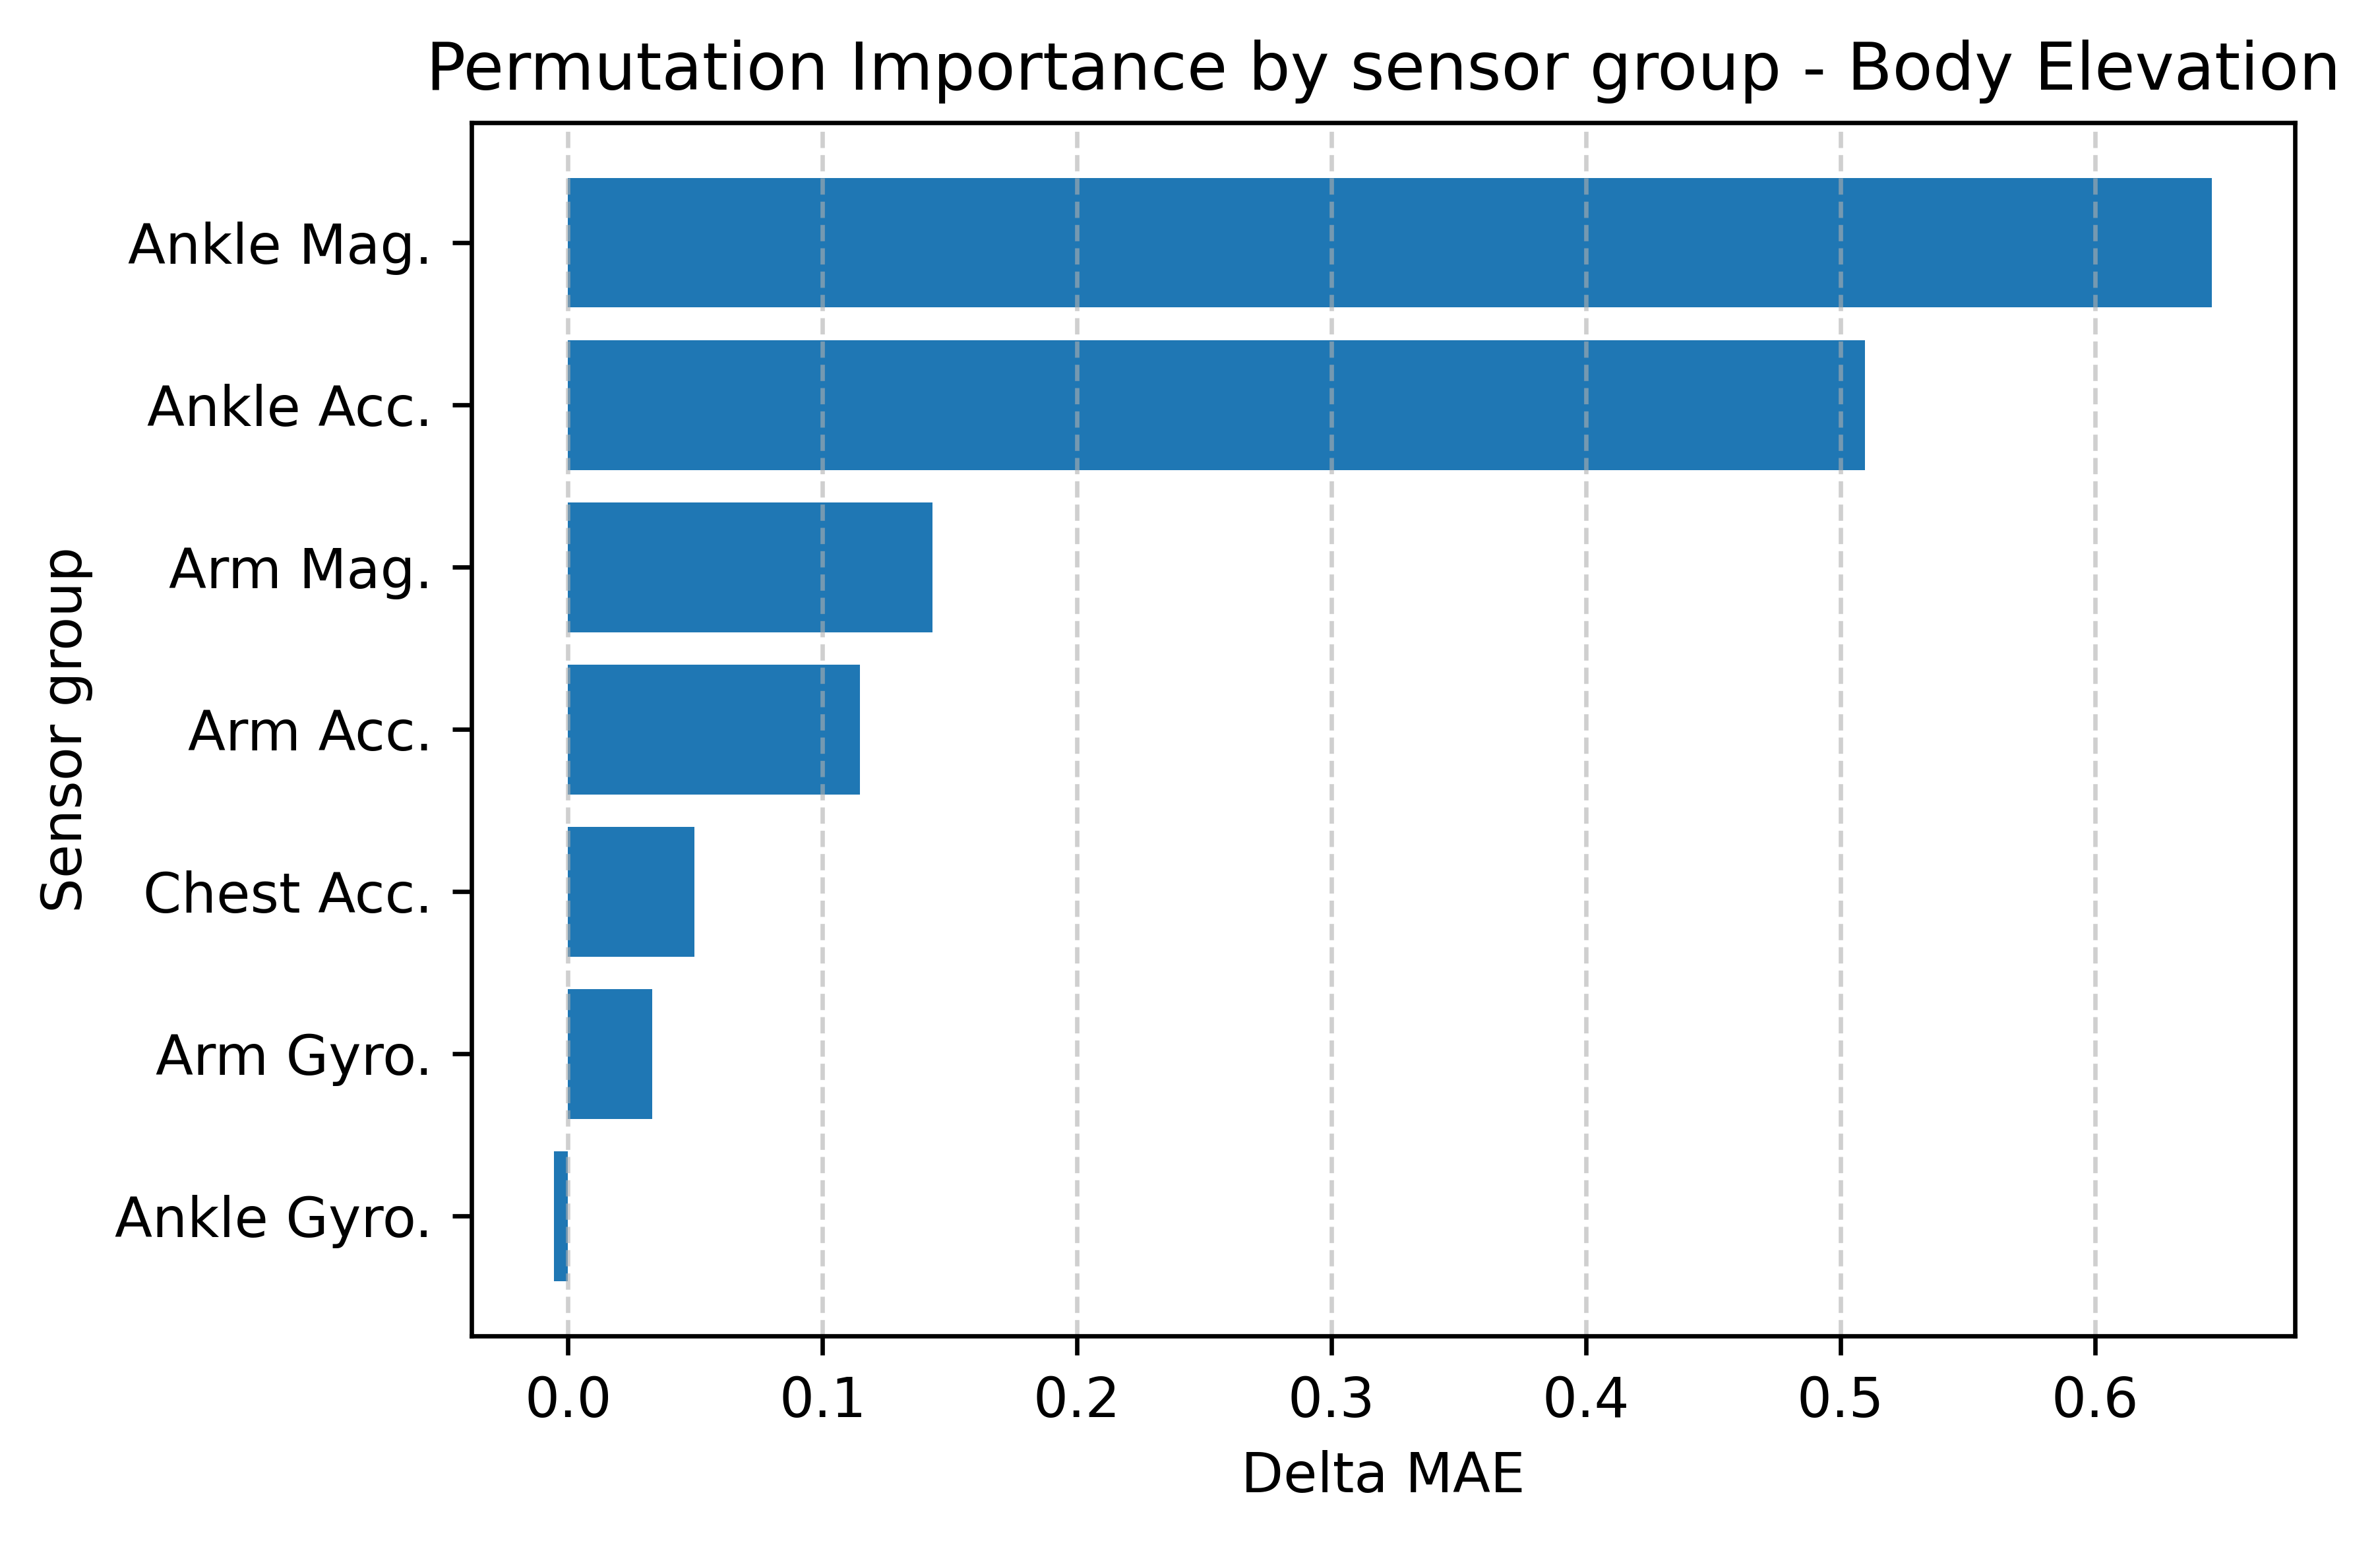

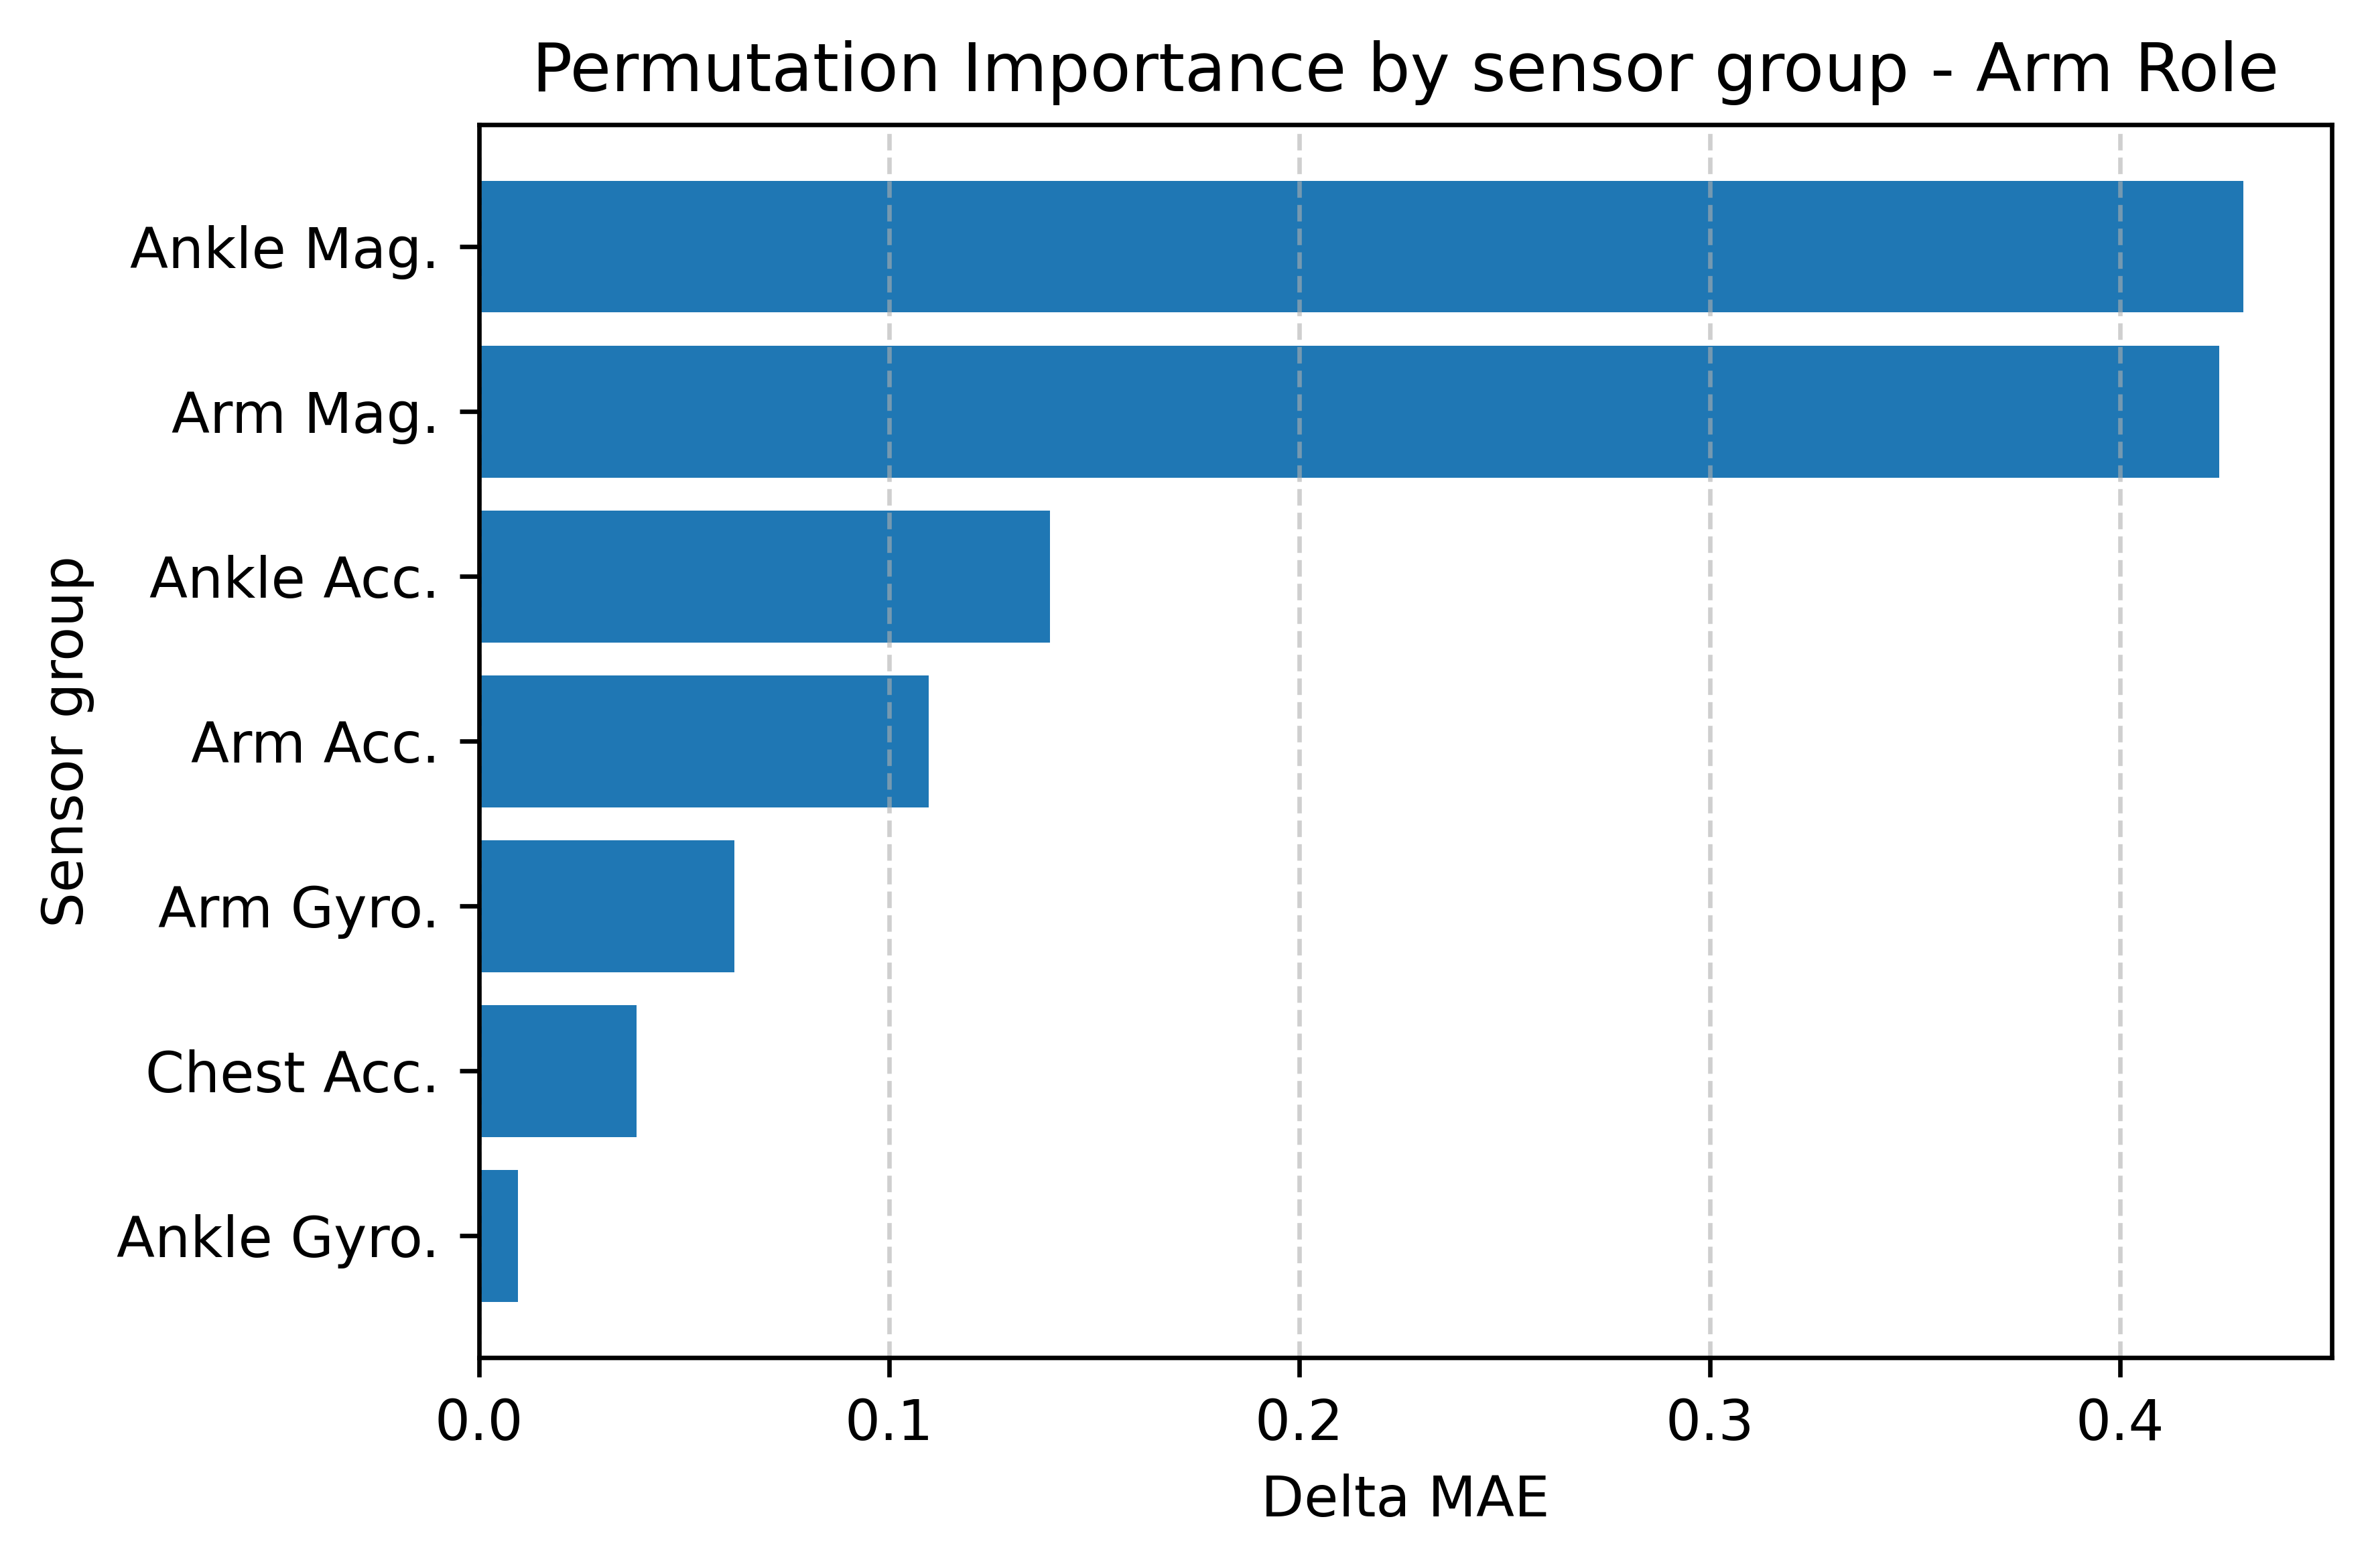

In [18]:
for i, perm_group in enumerate(perm_per_group):
    perm_imp = pd.DataFrame(zip(SENSOR_NICE_NAMES, perm_group), columns=['sensor', 'delta_mae'])
    perm_imp_plot = perm_imp.sort_values('delta_mae', ascending=True)

    plt.figure(figsize=(6, 4), dpi=600)
    plt.barh(perm_imp_plot['sensor'], perm_imp_plot['delta_mae'])
    plt.xlabel('Delta MAE')
    plt.ylabel('Sensor group')
    plt.title('Permutation Importance by sensor group - ' + CONCEPT_NICE_NAMES[i])
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'figures/no_mask_perm_imp_{CONCEPT_NAMES[i]}.pdf', bbox_inches='tight')
    plt.show()

## Concepts to Labels

In [19]:
# test both sequential and independent bottlenecks

seq_train_concepts_cbm = sensors_to_concepts.predict(train_sensors_groups)
seq_test_concepts_cbm = sensors_to_concepts.predict(test_sensors_groups)
ind_train_concepts_cbm = train_concepts
ind_test_concepts_cbm = sensors_to_concepts.predict(test_sensors_groups)
    
print('seq_train_concepts:', seq_train_concepts_cbm.shape)
print('seq_test_concepts:', seq_test_concepts_cbm.shape)
print('ind_train_concepts:', ind_train_concepts_cbm.shape)
print('ind_test_concepts:', ind_test_concepts_cbm.shape)
print('train_labels:', train_labels.shape)
print('test_labels:', test_labels.shape)

  4/172 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step

172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step
seq_train_concepts: (5502, 8)
seq_test_concepts: (1359, 8)
ind_train_concepts: (5502, 8)
ind_test_concepts: (1359, 8)
train_labels: (5502,)
test_labels: (1359,)


### Logistic Regression

In [20]:
def build_lr():
    model = Sequential()
    model.add(Dense(len(LABEL_NAMES), activation='softmax'))
    return model

Epoch 1/30


86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5253 - loss: 1.3288  
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8126 - loss: 0.5403  
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - accuracy: 0.9222 - loss: 0.3906
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - accuracy: 0.9707 - loss: 0.3151
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9762 - loss: 0.2653  
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9767 - loss: 0.2295  
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - accuracy: 0.9766 - loss: 0.2027
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - accuracy: 0.9766 - loss: 0.1820
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9764 - loss: 0.1658  
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9766 - loss: 0.1528  
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9766 - loss: 0.1423  
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 

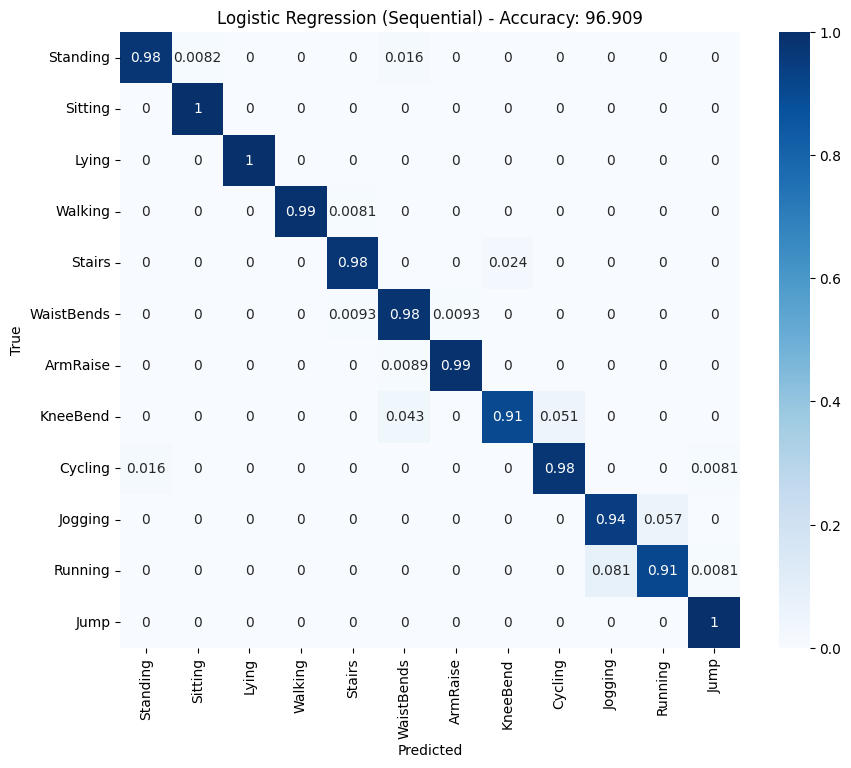

In [21]:
# sequential
lr_seq = build_lr()
lr_seq.compile(optimizer=Adam(learning_rate=1e-2), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lr_seq.fit(seq_train_concepts_cbm, train_labels, epochs=30, batch_size=64, verbose=1)
score = lr_seq.evaluate(seq_test_concepts_cbm, test_labels, verbose=0)[1] * 100

lr_seq_pred = lr_seq.predict(seq_test_concepts_cbm)
lr_seq_pred = np.argmax(lr_seq_pred, axis=1)
cm = confusion_matrix(test_labels, lr_seq_pred, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2g', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Logistic Regression (Sequential) - Accuracy: %.3f' % score)
plt.savefig('figures/no_mask_lr_seq_cm.pdf', bbox_inches='tight')
plt.show()

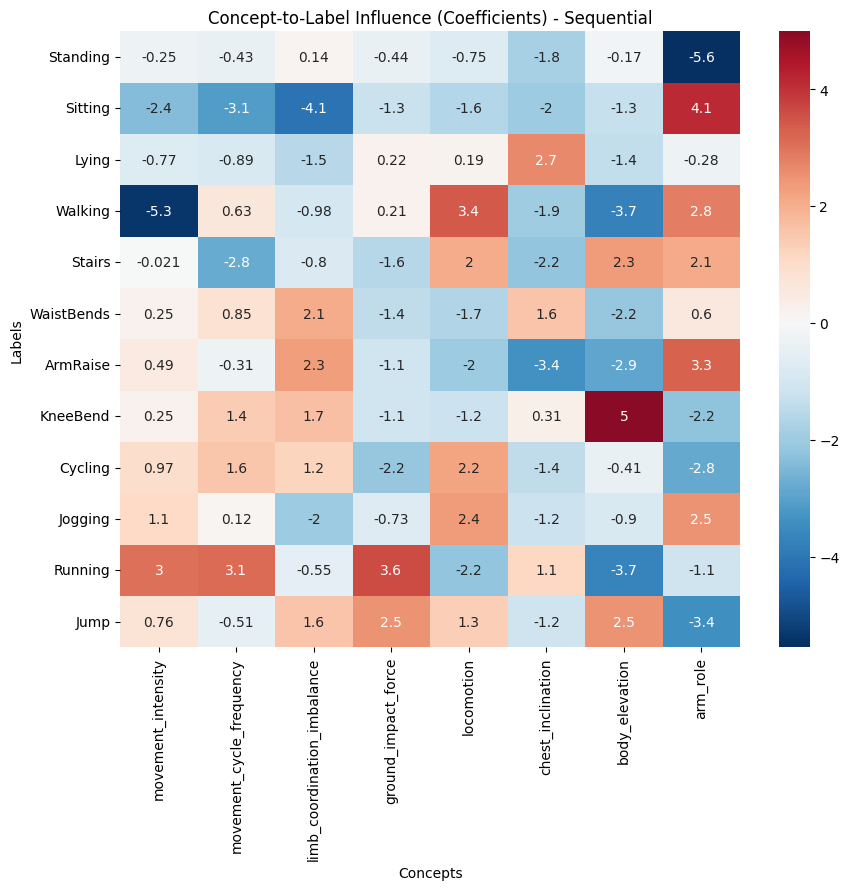

In [22]:
coef_df = pd.DataFrame(
    lr_seq.weights[0].numpy().T, 
    index = LABEL_NAMES, 
    columns = CONCEPT_NAMES
)

plt.figure(figsize=(10, 8))
sns.heatmap(coef_df, annot=True, cmap='RdBu_r', center=0)
plt.title('Concept-to-Label Influence (Coefficients) - Sequential')
plt.xlabel('Concepts')
plt.ylabel('Labels')
plt.savefig('figures/no_mask_lr_seq_coef.pdf', bbox_inches='tight')
plt.show()

Epoch 1/30


86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0865 - loss: 3.0203 
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1158 - loss: 2.4906  
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2085 - loss: 2.0746  
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4268 - loss: 1.7497  
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6080 - loss: 1.4914  
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6654 - loss: 1.2836  
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - accuracy: 0.7299 - loss: 1.1168
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.7783 - loss: 0.9835
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8015 - loss: 0.8768  
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8410 - loss: 0.7906  
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9077 - loss: 0.7199
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step - accuracy: 0

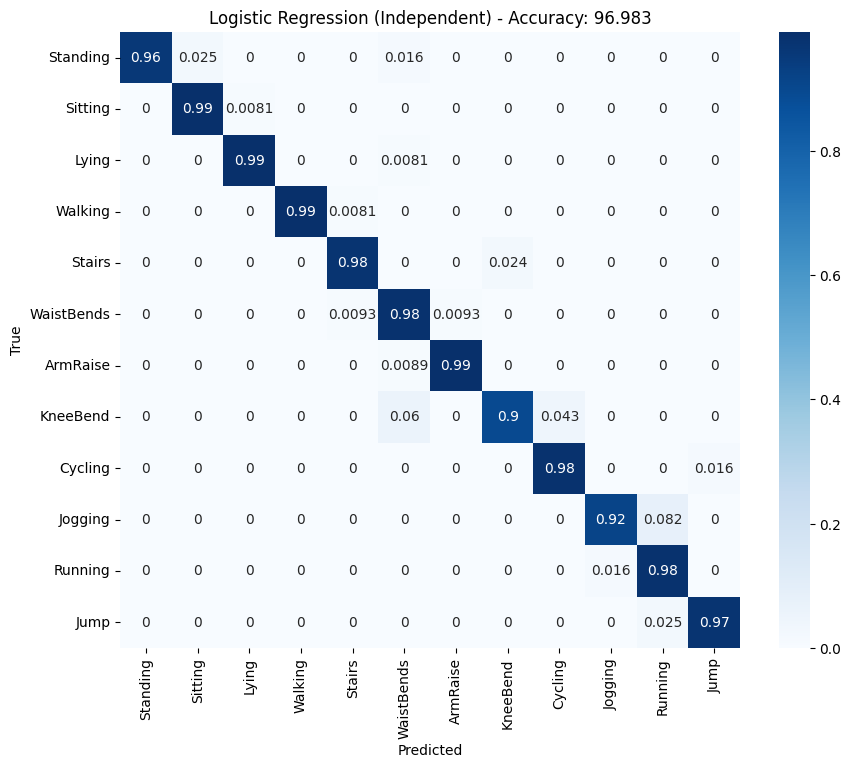

In [23]:
# independent
lr_ind = build_lr()
lr_ind.compile(optimizer=Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lr_ind.fit(ind_train_concepts_cbm, train_labels, epochs=30, batch_size=64)
score = lr_ind.evaluate(ind_test_concepts_cbm, test_labels, verbose=1)[1] * 100

lr_ind_pred = lr_ind.predict(ind_test_concepts_cbm)
lr_ind_pred = np.argmax(lr_ind_pred, axis=1)
cm = confusion_matrix(test_labels, lr_ind_pred, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2g', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Logistic Regression (Independent) - Accuracy: %.3f' % score)
plt.savefig('figures/no_mask_lr_ind_cm.pdf', bbox_inches='tight')
plt.show()

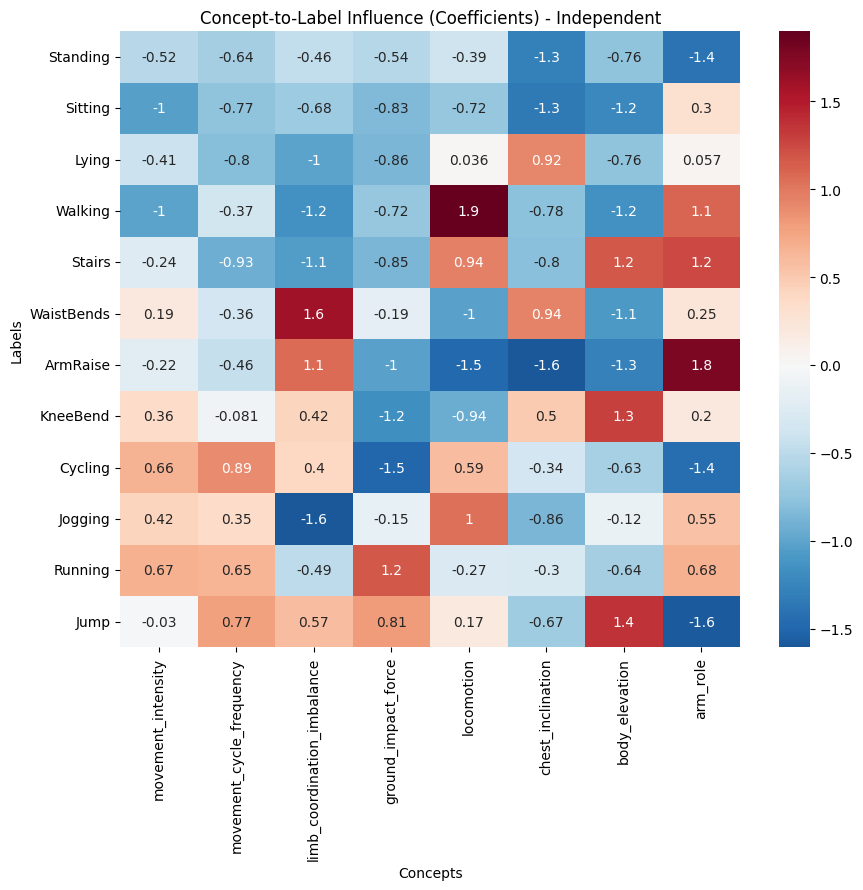

In [24]:
coef_df = pd.DataFrame(
    lr_ind.weights[0].numpy().T, 
    index = LABEL_NAMES, 
    columns = CONCEPT_NAMES
)

plt.figure(figsize=(10, 8))
sns.heatmap(coef_df, annot=True, cmap='RdBu_r', center=0)
plt.title('Concept-to-Label Influence (Coefficients) - Independent')
plt.xlabel('Concepts')
plt.ylabel('Labels')
plt.savefig('figures/no_mask_lr_ind_coef.pdf', bbox_inches='tight')
plt.show()